<a href="https://colab.research.google.com/github/bhuvighosh3/Forecasting-project/blob/main/Electricity_forecast_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats

In [4]:
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [5]:
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Initial Cleaning:

We load the electricity consumption dataset (15-minute resolution) and:

- Parse timestamps.
- Set datetime index.
- Sort chronologically.
- Handle missing values.
- Remove rows where all clients have zero consumption.

In [13]:
df = pd.read_csv(
    '/content/LD2011_2014 2.txt',
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'
)

df.iloc[:,0] = pd.to_datetime(df.iloc[:,0])  # convert first column
df = df.set_index(df.columns[0])

print(df.index[:5])

DatetimeIndex(['2011-01-01 00:15:00', '2011-01-01 00:30:00',
               '2011-01-01 00:45:00', '2011-01-01 01:00:00',
               '2011-01-01 01:15:00'],
              dtype='datetime64[ns]', name='Unnamed: 0', freq=None)


In [14]:
df.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
df = df.sort_index()

In [16]:
print("Total missing:", df.isna().sum().sum())

Total missing: 195


In [17]:
df = df.fillna(method='ffill')

In [18]:
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
print("Zero rows (all clients zero):", (df == 0).all(axis=1).sum())

Shape: (19962, 370)
Nulls: 0
Zero rows (all clients zero): 0


In [19]:
df = df[(df != 0).any(axis=1)]
print("Shape after dropping all-zero rows:", df.shape)

Shape after dropping all-zero rows: (19962, 370)


## 2. Cross-Client Correlation Analysis:

We compute the correlation matrix between all clients and visualize it using a heatmap.  
We also examine highly correlated client pairs (r > 0.85).

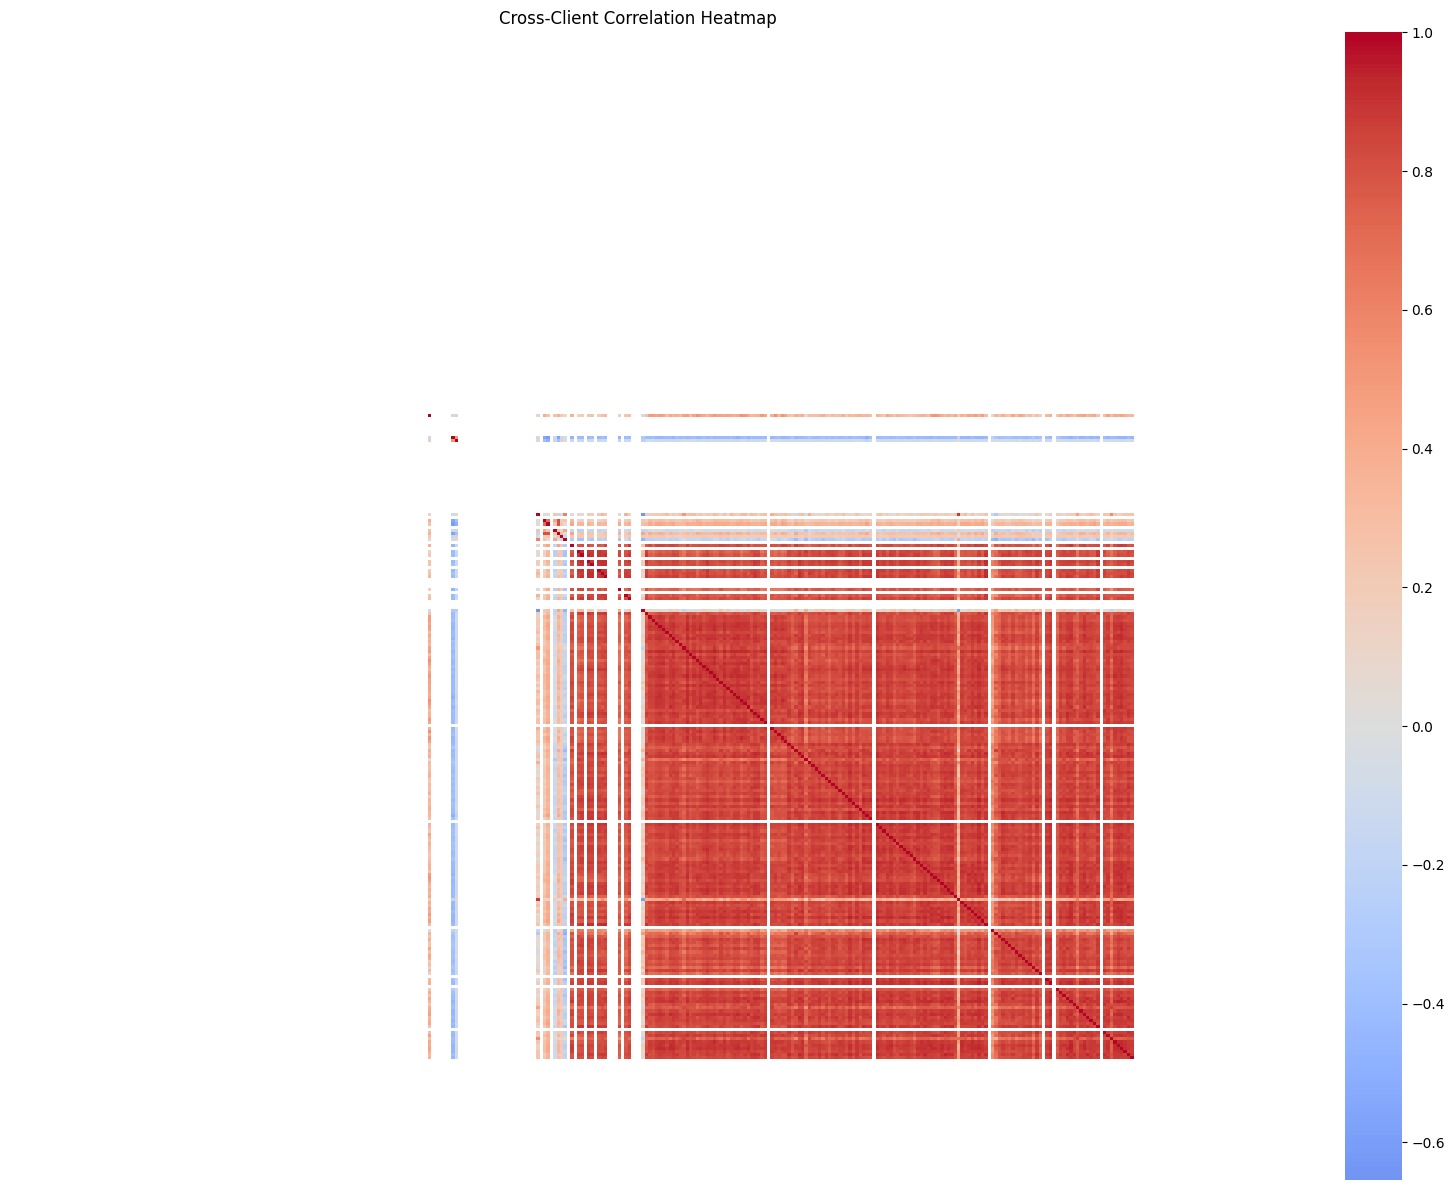

In [20]:
corr_matrix = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.title("Cross-Client Correlation Heatmap")
plt.tight_layout()
plt.show()

In [21]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
flat_corr = upper_tri.stack()
print("\nCorrelation stats across all client pairs:")
print(flat_corr.describe())


Correlation stats across all client pairs:
count    12720.000000
mean         0.721714
std          0.279393
min         -0.654339
25%          0.763179
50%          0.826484
75%          0.863448
max          0.949109
dtype: float64


In [22]:
high_corr = flat_corr[flat_corr > 0.85]
print(f"\nPairs with r > 0.85: {len(high_corr)}")
print(high_corr.sort_values(ascending=False).head(20))


Pairs with r > 0.85: 4407
MT_277  MT_286    0.949109
MT_286  MT_307    0.945536
MT_200  MT_208    0.945060
MT_313  MT_327    0.944005
MT_248  MT_252    0.943670
        MT_286    0.942758
MT_313  MT_328    0.940037
MT_276  MT_330    0.939077
MT_318  MT_330    0.939047
MT_248  MT_307    0.938865
MT_200  MT_211    0.938003
        MT_328    0.937972
MT_256  MT_286    0.937701
        MT_277    0.936133
MT_275  MT_286    0.935614
MT_193  MT_200    0.935444
MT_200  MT_204    0.934926
MT_317  MT_328    0.934878
MT_270  MT_286    0.934762
MT_216  MT_228    0.934507
dtype: float64


In [23]:
scaler = StandardScaler()
# Transpose: each client is a sample, each timestep is a feature
X = scaler.fit_transform(df.T)  # shape: (n_clients, n_timesteps)

## 3. PCA for Dimensionality Reduction and KMeans Clustering

Steps:
1. Standardize each client time series.
2. Apply PCA (10 components).
3. Use the Elbow Method to select the number of clusters.
4. Apply KMeans clustering.

In [24]:
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)
print(f"\nPCA explained variance (10 components): {pca.explained_variance_ratio_.sum():.2%}")


PCA explained variance (10 components): 99.92%


## 4. Build Cluster-Level Mean Series

For each cluster:
- Compute mean consumption across members.
- Store cleaned mean time series.


PCA explained variance (10 components): 99.92%


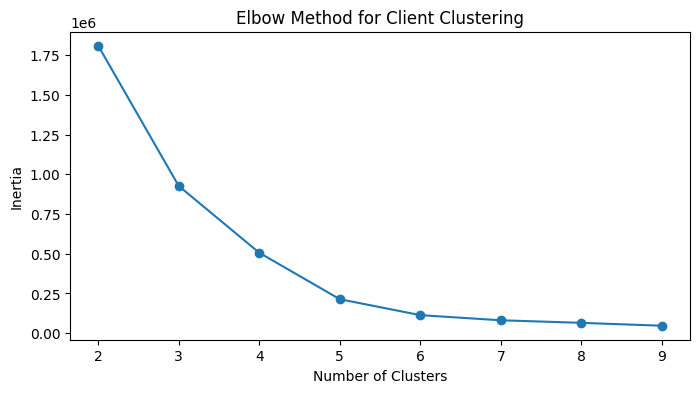


Clients per cluster:
 cluster
0    317
4     40
3      9
5      2
2      1
1      1
Name: count, dtype: int64

Cluster series built:
  Cluster 0: 317 clients | series length: 19962 | mean value: 59.7681
  Cluster 1: 1 clients | series length: 19962 | mean value: 13762.1397
  Cluster 2: 1 clients | series length: 19962 | mean value: 24020.6058
  Cluster 3: 9 clients | series length: 19962 | mean value: 2502.1450
  Cluster 4: 40 clients | series length: 19962 | mean value: 755.8670
  Cluster 5: 2 clients | series length: 19962 | mean value: 6876.2347


In [25]:
# Get only actual client columns (exclude 'global_mean')
client_cols = [col for col in df.columns if col != 'global_mean']

scaler = StandardScaler()
X = scaler.fit_transform(df[client_cols].T)  # shape: (n_clients, n_timesteps)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)
print(f"\nPCA explained variance (10 components): {pca.explained_variance_ratio_.sum():.2%}")

inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Client Clustering")
plt.show()

K_BEST = 6
km = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
labels = km.fit_predict(X_pca)
client_clusters = pd.Series(labels, index=client_cols, name='cluster')  # ← client_cols, not df.columns
print("\nClients per cluster:\n", client_clusters.value_counts())

# BUILD CLUSTER SERIES DICT:
cluster_series = {}
for c in range(K_BEST):
    members = client_clusters[client_clusters == c].index.tolist()
    mean_series = df[members].mean(axis=1)
    cluster_series[c] = {
        'mean'    : mean_series,
        'members' : members,
        'n'       : len(members)
    }

print("\nCluster series built:")
for c in range(K_BEST):
    print(f"  Cluster {c}: {cluster_series[c]['n']} clients | "
          f"series length: {len(cluster_series[c]['mean'])} | "
          f"mean value: {cluster_series[c]['mean'].mean():.4f}")

In [26]:
df['global_mean'] = df.drop(columns='global_mean', errors='ignore').mean(axis=1)

cluster_means = {}
for c in range(K_BEST):
    members = client_clusters[client_clusters == c].index.tolist()
    cluster_means[f'cluster_{c}_mean'] = df[members].mean(axis=1)

cluster_df = pd.DataFrame(cluster_means, index=df.index)
cluster_df['global_mean'] = df['global_mean']

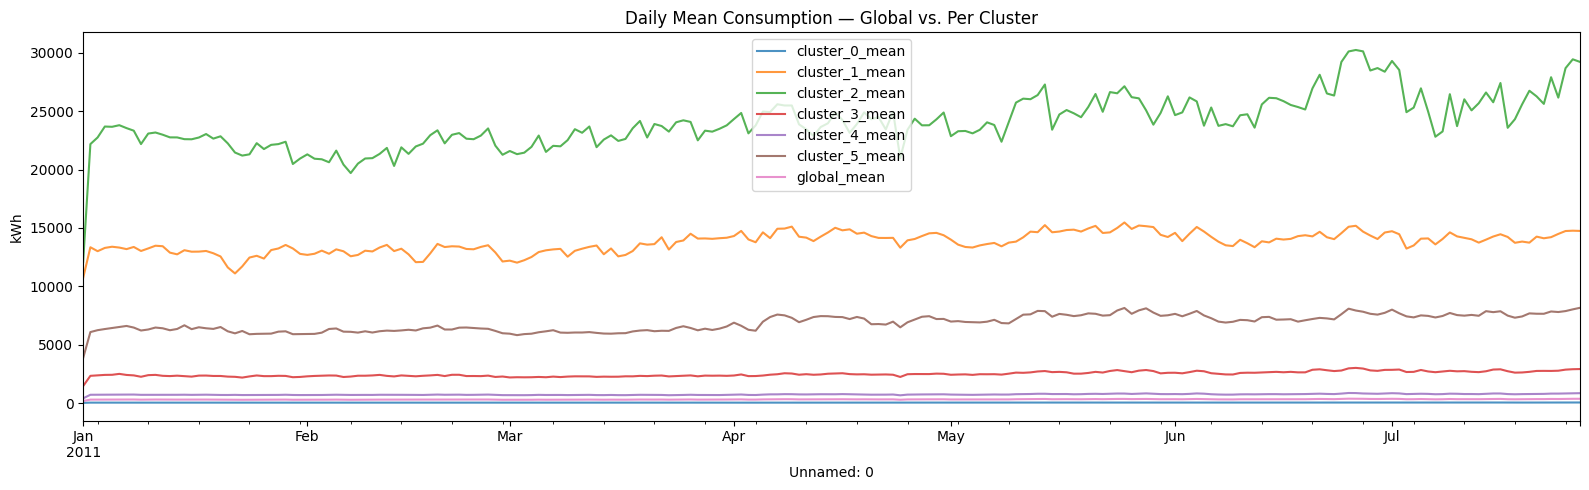

In [27]:
cluster_df.resample('D').mean().plot(figsize=(16, 5), alpha=0.8)
plt.title("Daily Mean Consumption — Global vs. Per Cluster")
plt.ylabel("kWh")
plt.tight_layout()
plt.show()

## 5. Time Series Diagnostics:

For each cluster:
- Basic statistics (mean, std, skew, kurtosis).
- Missing timestamps check.
- Outlier detection (IQR and Z-score).
- Stationarity tests (ADF and KPSS).
- Autocorrelation test (Ljung-Box).
- Seasonality strength (hour-of-day and day-of-week coefficient of variation).


────────────────────────────────────────────────────────────
CLUSTER 0  |  317 clients
────────────────────────────────────────────────────────────

[1] Basic Statistics
    Length       : 19,962 observations
    Date range   : 2011-01-01 00:15:00 → 2011-07-27 22:30:00
    Mean         : 59.7681
    Std          : 16.2664
    Min          : 29.2567
    Max          : 92.5747
    Skewness     : -0.4260
    Kurtosis     : -1.2037

[2] Missing Values & Gaps
    NaN values   : 0
    Zero values  : 0 (0.00%)
    Missing timestamps : 0

[3] Outlier Detection
    IQR outliers (3×IQR) : 0 (0.00%)
    Z-score outliers (>3): 0  (0.00%)
    → Capped to [-46.4944, 161.4748]

[4] Stationarity Tests
    ADF Test     : stat=-36.4374, p=0.0000  → STATIONARY ✓
    KPSS Test    : stat=13.3536, p=0.0100  → NON-STATIONARY ✗

[5] Autocorrelation — Ljung-Box Test
    Lag    96 (=1 day ): stat=630724.82, p=0.0000  → significant ✓
    Lag   672 (=7 days): stat=4297687.36, p=0.0000  → significant ✓

[6] Seaso

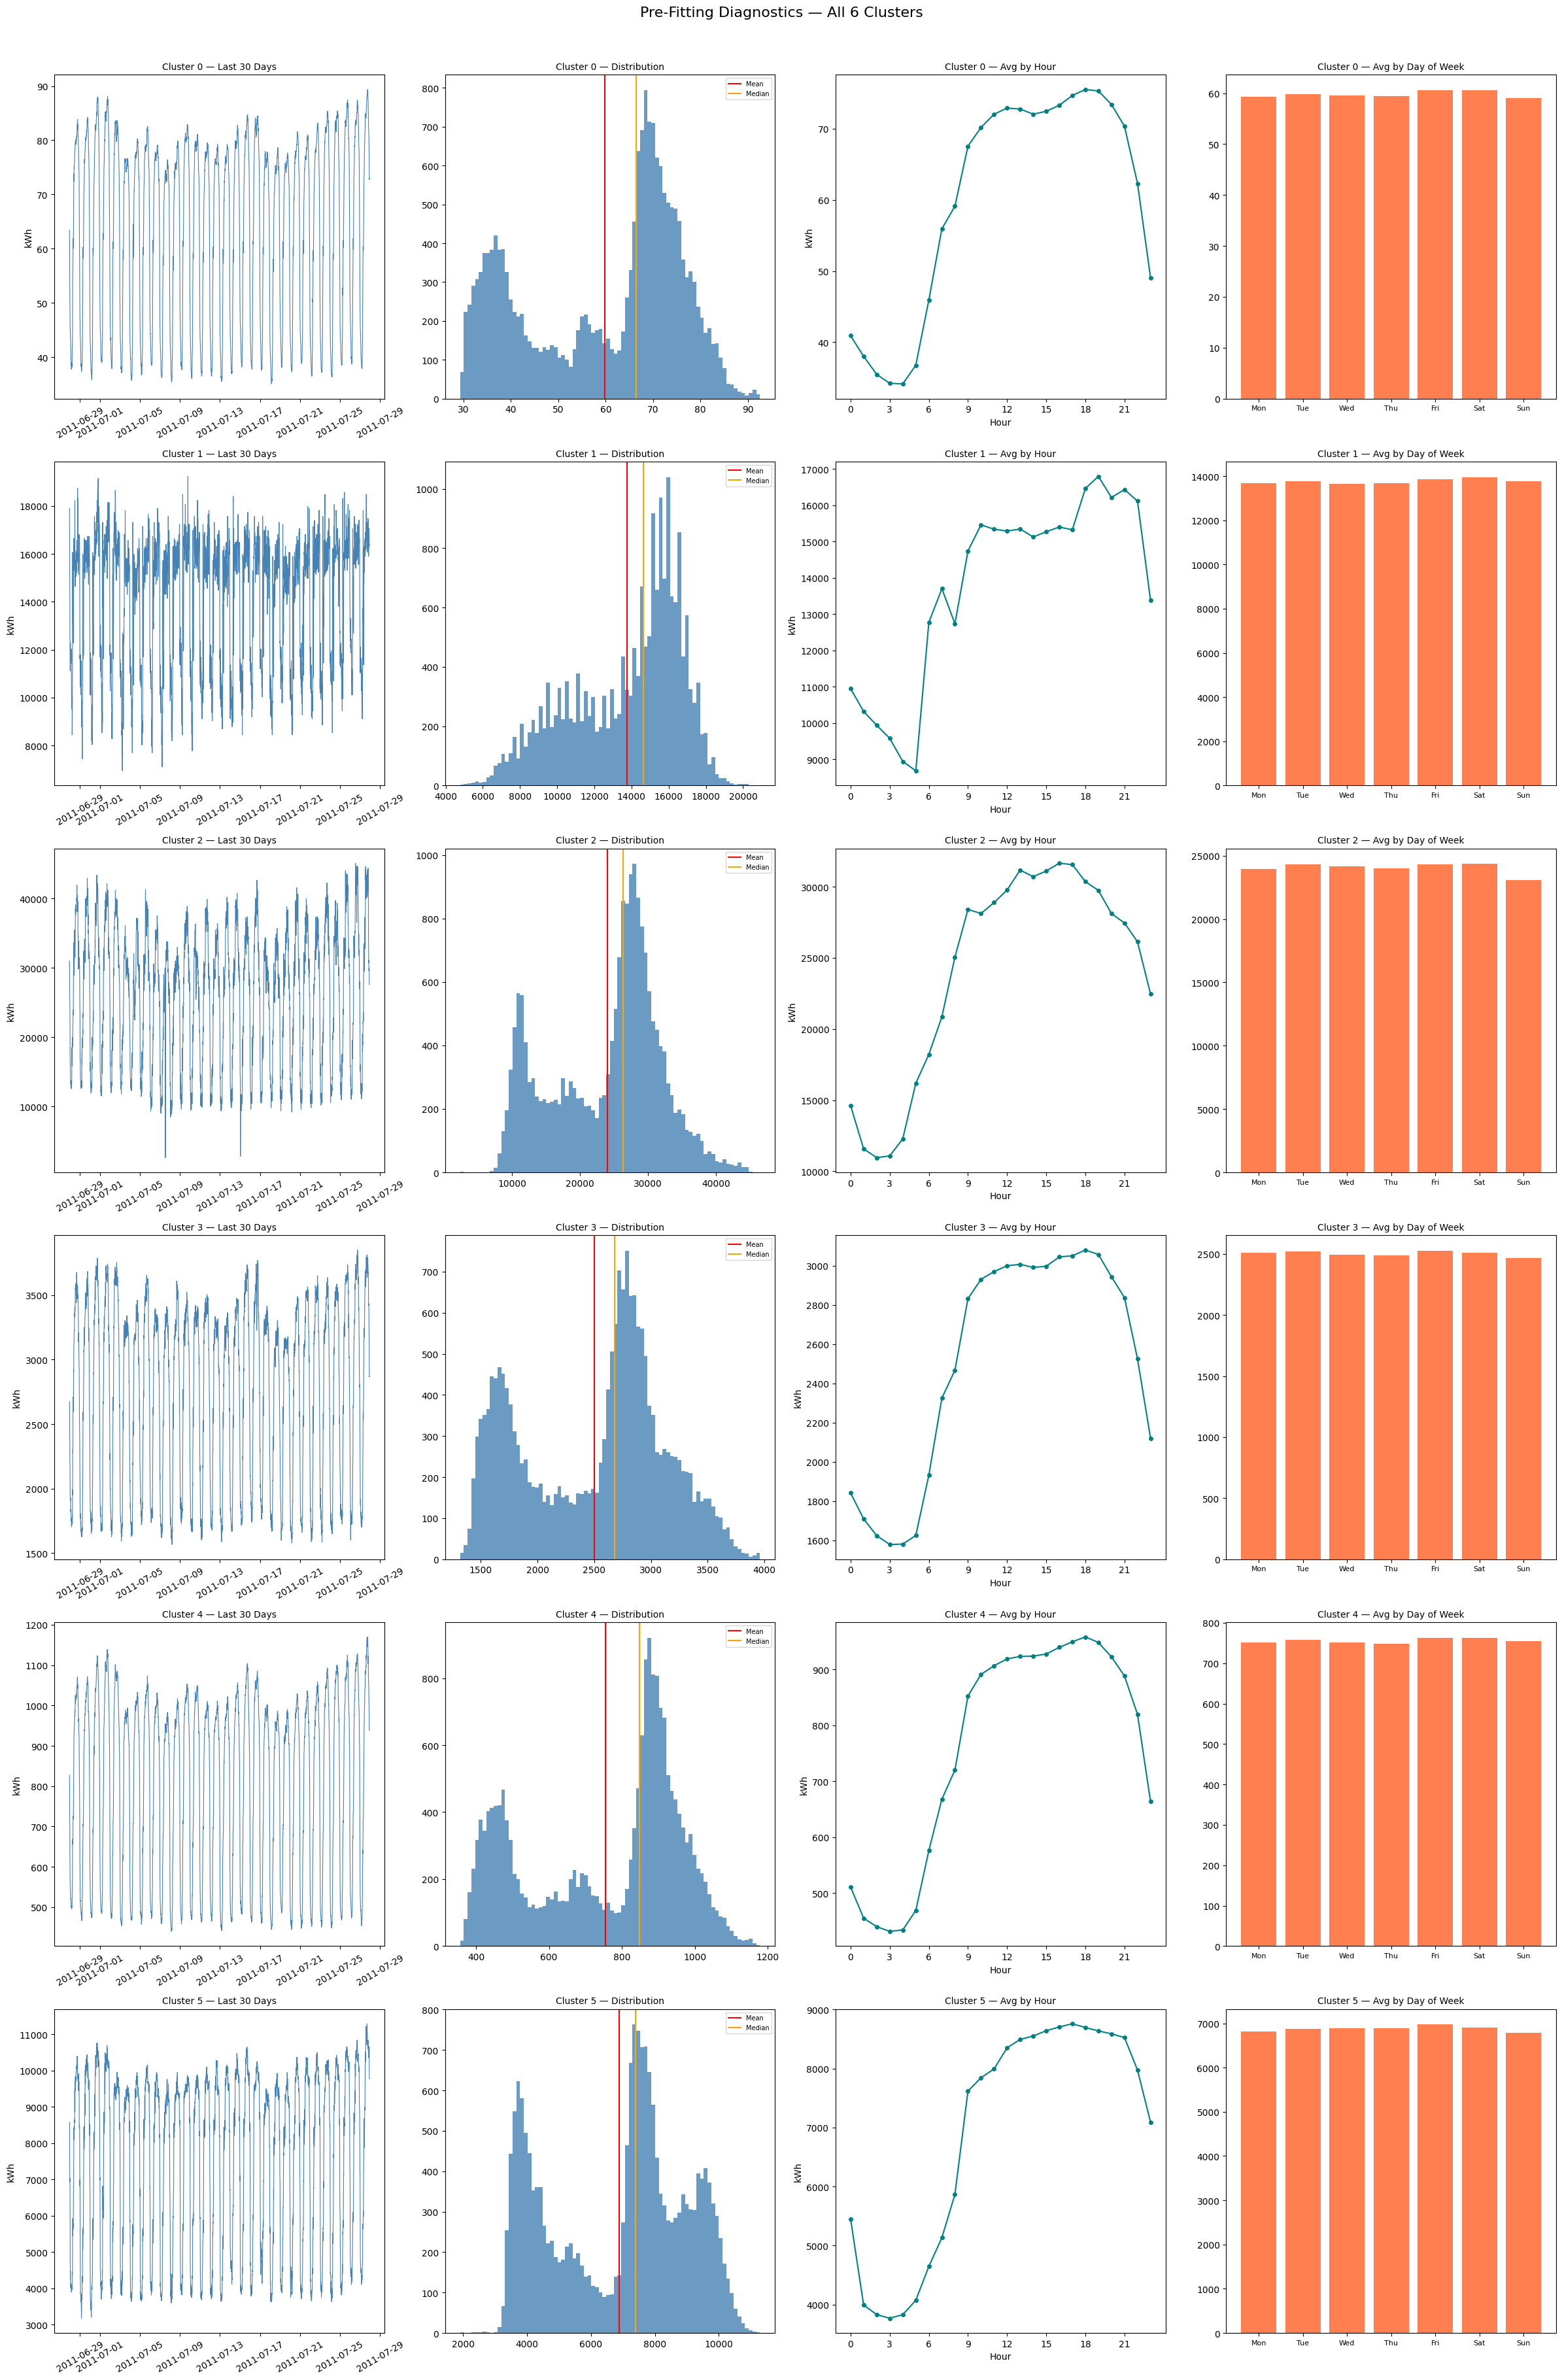

In [28]:
diag_results = []

for c in range(K_BEST):
    print(f"\n{'─'*60}")
    print(f"CLUSTER {c}  |  {cluster_series[c]['n']} clients")
    print(f"{'─'*60}")

    series = cluster_series[c]['mean'].copy()
    series.index = pd.to_datetime(series.index)
    if series.index.tz is not None:
        series.index = series.index.tz_localize(None)

    row = {'Cluster': c, 'N_clients': cluster_series[c]['n']}

    print(f"\n[1] Basic Statistics")
    print(f"    Length       : {len(series):,} observations")
    print(f"    Date range   : {series.index.min()} → {series.index.max()}")
    print(f"    Mean         : {series.mean():.4f}")
    print(f"    Std          : {series.std():.4f}")
    print(f"    Min          : {series.min():.4f}")
    print(f"    Max          : {series.max():.4f}")
    print(f"    Skewness     : {stats.skew(series):.4f}")
    print(f"    Kurtosis     : {stats.kurtosis(series):.4f}")
    row.update({'Mean': round(series.mean(), 4), 'Std': round(series.std(), 4),
                'Skew': round(stats.skew(series), 4)})

    print(f"\n[2] Missing Values & Gaps")
    null_count = series.isna().sum()
    zero_count = (series == 0).sum()
    print(f"    NaN values   : {null_count}")
    print(f"    Zero values  : {zero_count} ({100*zero_count/len(series):.2f}%)")

    expected_idx = pd.date_range(series.index.min(), series.index.max(), freq='15min')
    missing_ts   = expected_idx.difference(series.index)
    print(f"    Missing timestamps : {len(missing_ts)}")
    if len(missing_ts) > 0:
        print(f"    First gap    : {missing_ts[0]}")
        print(f"    Last gap     : {missing_ts[-1]}")
        # Reindex and forward-fill gaps
        series = series.reindex(expected_idx).ffill()
        print(f"    → Reindexed and forward-filled.")
    row.update({'NaNs': null_count, 'Zeros': zero_count, 'Missing_timestamps': len(missing_ts)})

    print(f"\n[3] Outlier Detection")
    Q1, Q3   = series.quantile(0.25), series.quantile(0.75)
    IQR      = Q3 - Q1
    iqr_out  = ((series < Q1 - 3 * IQR) | (series > Q3 + 3 * IQR)).sum()
    z_scores = np.abs(stats.zscore(series.dropna()))
    z_out    = (z_scores > 3).sum()
    print(f"    IQR outliers (3×IQR) : {iqr_out} ({100*iqr_out/len(series):.2f}%)")
    print(f"    Z-score outliers (>3): {z_out}  ({100*z_out/len(series):.2f}%)")

    lower_cap = Q1 - 3 * IQR
    upper_cap = Q3 + 3 * IQR
    series_clean = series.clip(lower=lower_cap, upper=upper_cap)
    print(f"    → Capped to [{lower_cap:.4f}, {upper_cap:.4f}]")
    row.update({'IQR_outliers': int(iqr_out), 'Zscore_outliers': int(z_out)})

    # STATIONARITY TESTS
    print(f"\n[4] Stationarity Tests")

    # ADF test — H0: unit root (non-stationary)
    # Use a sample for speed if series is very long
    sample = series_clean if len(series_clean) <= 50000 else series_clean.iloc[-50000:]

    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(sample.dropna(), autolag='AIC')
    adf_result = "STATIONARY ✓" if adf_p < 0.05 else "NON-STATIONARY ✗"
    print(f"    ADF Test     : stat={adf_stat:.4f}, p={adf_p:.4f}  → {adf_result}")

    # KPSS test — H0: stationary
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(sample.dropna(), regression='c', nlags='auto')
        kpss_result = "STATIONARY ✓" if kpss_p > 0.05 else "NON-STATIONARY ✗"
        print(f"    KPSS Test    : stat={kpss_stat:.4f}, p={kpss_p:.4f}  → {kpss_result}")
    except Exception as e:
        kpss_result = "ERROR"
        print(f"    KPSS Test    : skipped ({e})")

    row.update({'ADF_p': round(adf_p, 4), 'ADF_stationary': adf_p < 0.05,
                'KPSS_stationary': kpss_p > 0.05 if kpss_result != "ERROR" else None})

    # AUTOCORRELATION CHECK (Ljung-Box)
    print(f"\n[5] Autocorrelation — Ljung-Box Test")
    lb = acorr_ljungbox(sample.dropna(), lags=[96, 96*7], return_df=True)  # 1-day & 7-day lags
    for lag, row_lb in lb.iterrows():
        sig = "significant ✓" if row_lb['lb_pvalue'] < 0.05 else "not significant"
        print(f"    Lag {lag:>5} (={'1 day ' if lag==96 else '7 days'}): "
              f"stat={row_lb['lb_stat']:.2f}, p={row_lb['lb_pvalue']:.4f}  → {sig}")

    # SEASONALITY STRENGTH
    print(f"\n[6] Seasonality Strength (variance explained)")
    daily_hourly = series_clean.groupby(series_clean.index.hour).mean()
    weekly_daily = series_clean.groupby(series_clean.index.dayofweek).mean()

    # Coefficient of variation as proxy for seasonality strength
    daily_cv  = daily_hourly.std()  / daily_hourly.mean()
    weekly_cv = weekly_daily.std() / weekly_daily.mean()
    print(f"    Intraday CV  (hour-of-day pattern strength) : {daily_cv:.4f}")
    print(f"    Weekly CV    (day-of-week pattern strength) : {weekly_cv:.4f}")
    row.update({'Intraday_CV': round(daily_cv, 4), 'Weekly_CV': round(weekly_cv, 4)})

    # Store cleaned series back
    cluster_series[c]['mean_clean'] = series_clean
    diag_results.append(row)

print("DIAGNOSTIC SUMMARY TABLE")
print("=" * 70)
diag_df = pd.DataFrame(diag_results).set_index('Cluster')
print(diag_df.to_string())

fig, axes = plt.subplots(6, 4, figsize=(24, 36))

for c in range(K_BEST):
    series = cluster_series[c]['mean_clean']
    ax_ts, ax_dist, ax_hour, ax_dow = axes[c]

    # (a) Time series — last 30 days
    last30 = series.last('30D')
    ax_ts.plot(last30.index, last30.values, lw=0.8, color='steelblue')
    ax_ts.set_title(f"Cluster {c} — Last 30 Days", fontsize=10)
    ax_ts.set_ylabel("kWh"); ax_ts.tick_params(axis='x', rotation=30)

    # (b) Distribution
    ax_dist.hist(series, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    ax_dist.axvline(series.mean(), color='red',    lw=1.5, label='Mean')
    ax_dist.axvline(series.median(), color='orange', lw=1.5, label='Median')
    ax_dist.set_title(f"Cluster {c} — Distribution", fontsize=10)
    ax_dist.legend(fontsize=7)

    # (c) Intraday pattern (hour of day)
    hourly = series.groupby(series.index.hour).mean()
    ax_hour.plot(hourly.index, hourly.values, marker='o', ms=4, color='teal')
    ax_hour.set_title(f"Cluster {c} — Avg by Hour", fontsize=10)
    ax_hour.set_xlabel("Hour"); ax_hour.set_ylabel("kWh")
    ax_hour.set_xticks(range(0, 24, 3))

    # (d) Weekly pattern (day of week)
    dow_mean = series.groupby(series.index.dayofweek).mean()
    ax_dow.bar(dow_mean.index, dow_mean.values, color='coral', edgecolor='none')
    ax_dow.set_title(f"Cluster {c} — Avg by Day of Week", fontsize=10)
    ax_dow.set_xticks(range(7))
    ax_dow.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=8)

plt.suptitle("Pre-Fitting Diagnostics — All 6 Clusters", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
## Cluster 0 — Prophet (cp=0.03):

- **317 clients** averaged — largest aggregate, lowest noise
- Skew=-0.43 (mild), Intraday CV=0.265, zero outliers, zero zeros
- Large aggregate produces stable trend — low changepoint prior (0.03)
- Yearly seasonality OFF — only 6 months of data available
- **Verdict: Prophet is the natural fit.**

SyntaxError: invalid character '—' (U+2014) (1361303841.py, line 3)

CLUSTER 0 — Prophet  (317 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 9.37%
    [Prophet test-15%]  MAE=2.56  MAPE=3.99%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: MAPE = 4.33%
    Region 2: MAPE = 3.43%
    Region 3: MAPE = 3.88%
    Region 4: MAPE = 4.32%


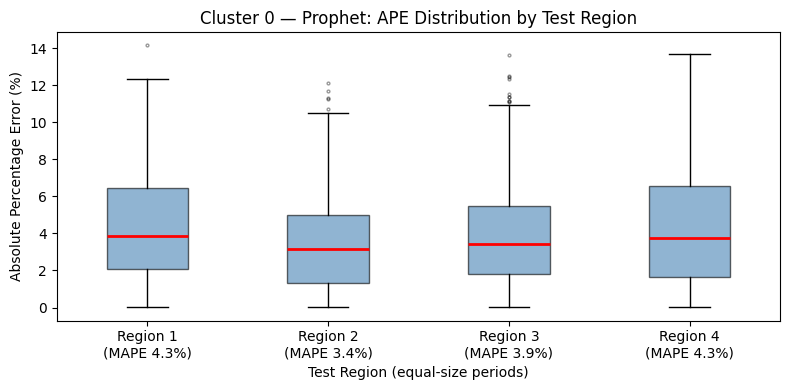

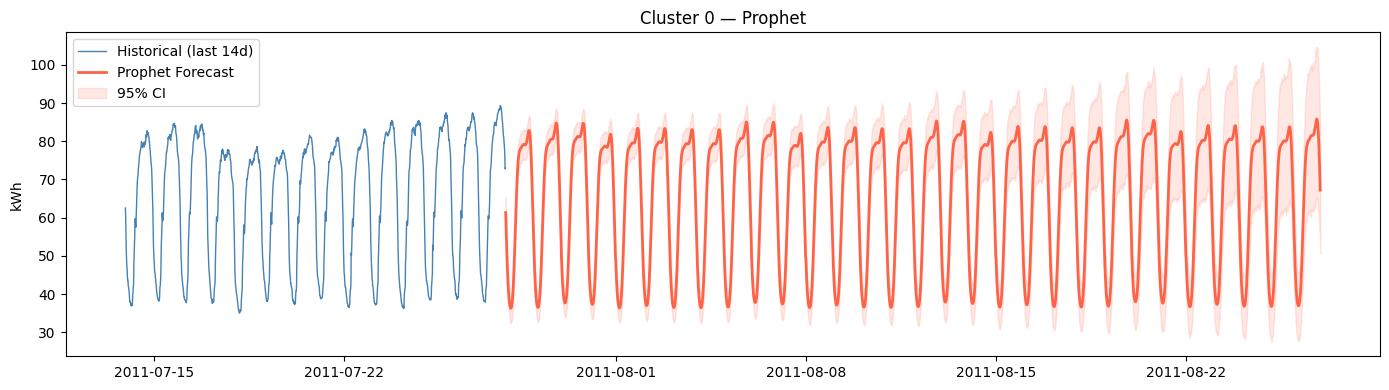

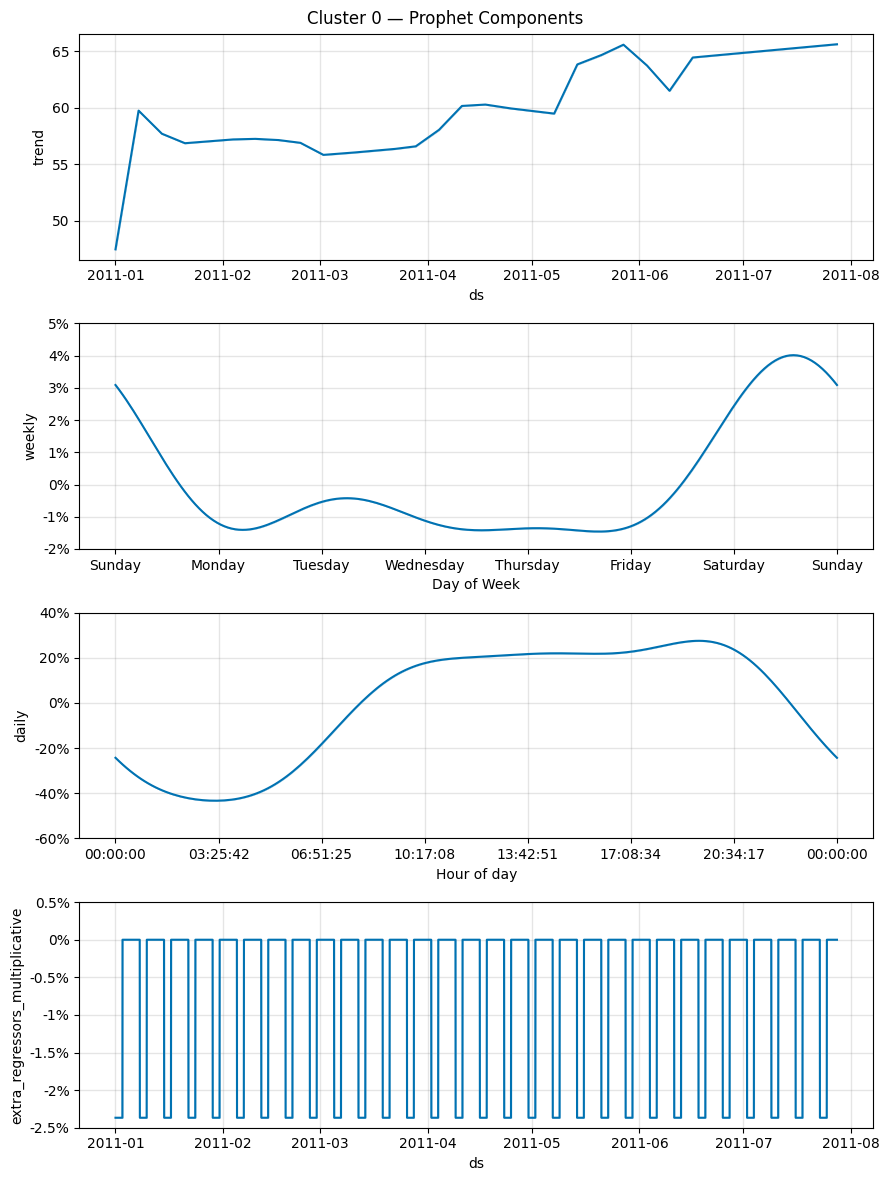

CLUSTER 1 — Prophet + SARIMA hourly  (1 client)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Prophet Validation MAPE: 10.21%
    [Prophet test-15%]  MAE=1023.63  MAPE=7.69%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: MAPE = 8.29%
    Region 2: MAPE = 7.57%
    Region 3: MAPE = 7.17%
    Region 4: MAPE = 7.70%


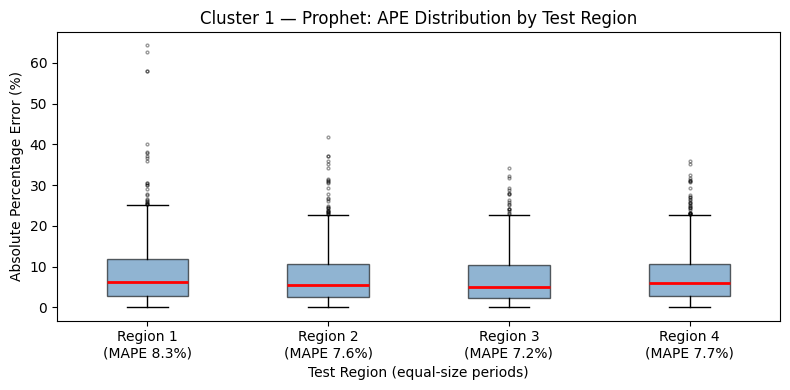

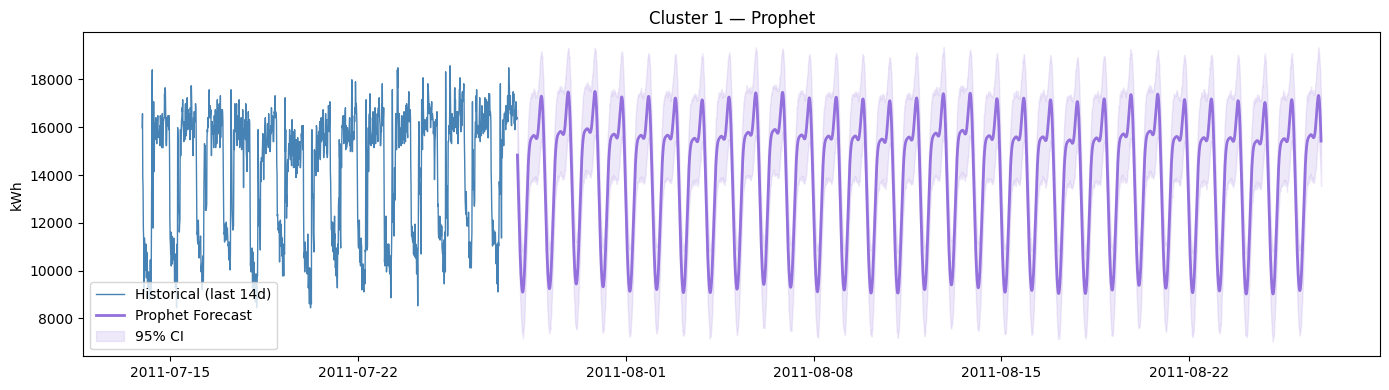

  SARIMA train: 3493 hours | val: 749 hours | test: 749 hours
  SARIMA Validation MAPE: 7.33%
    [SARIMA hourly test-15%]  MAE=4599.98  MAPE=32.94%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: MAPE = 14.58%
    Region 2: MAPE = 27.99%
    Region 3: MAPE = 40.52%
    Region 4: MAPE = 48.57%


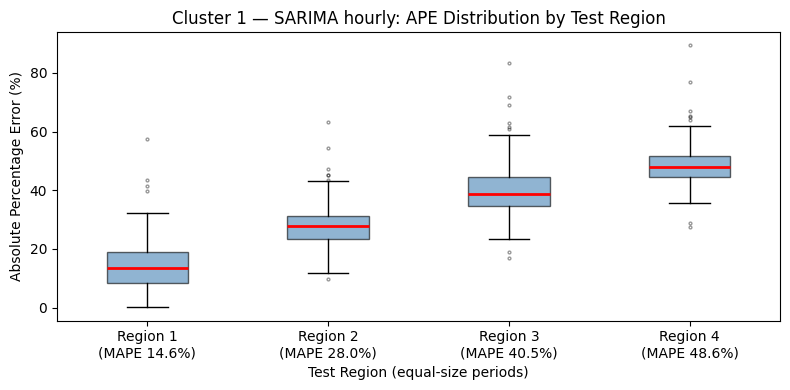

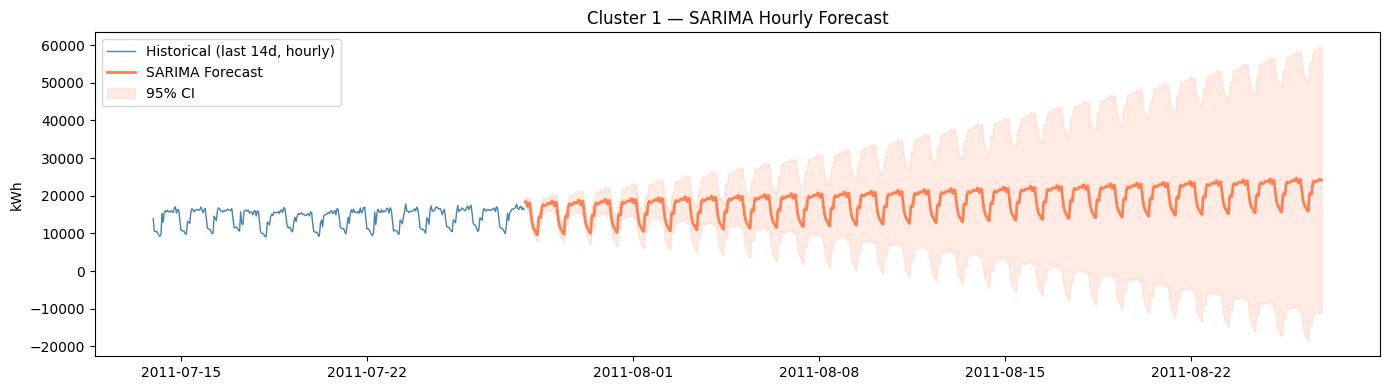

CLUSTER 2 — Prophet  (1 client, highest CV)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 12.44%
    [Prophet test-15%]  MAE=3014.42  MAPE=13.61%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: MAPE = 9.11%
    Region 2: MAPE = 17.38%
    Region 3: MAPE = 15.22%
    Region 4: MAPE = 12.73%


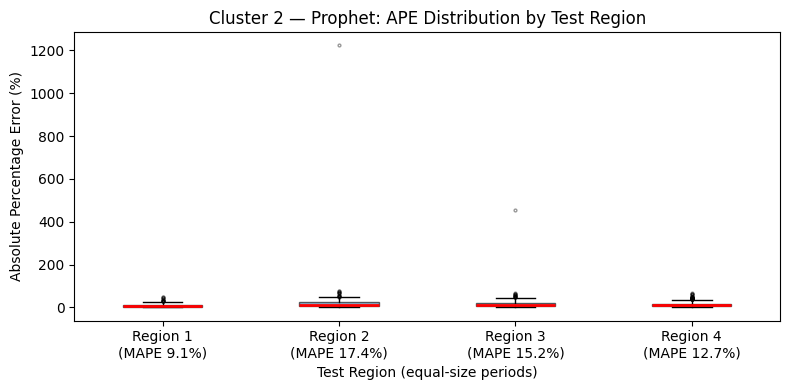

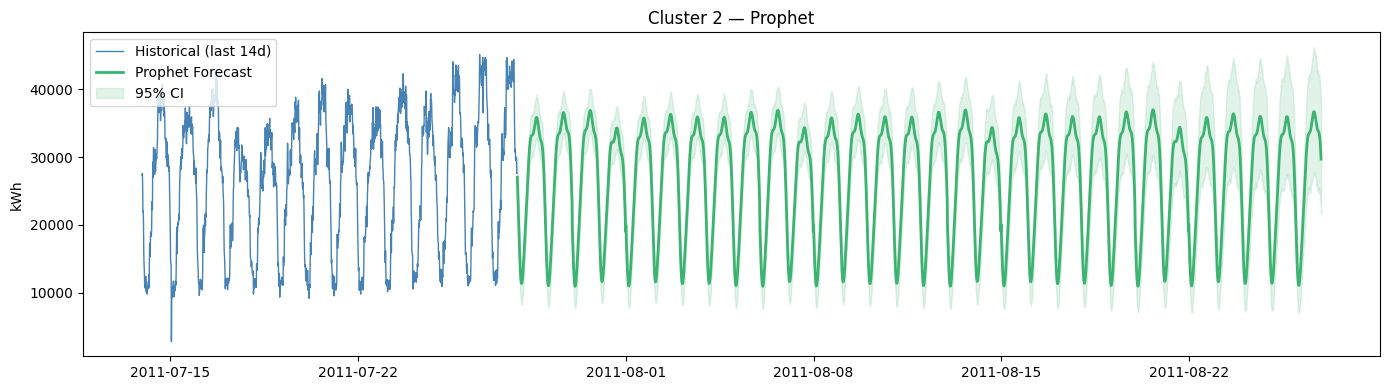

CLUSTER 3 — Prophet  (9 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 10.15%
    [Prophet test-15%]  MAE=134.27  MAPE=5.01%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: MAPE = 4.99%
    Region 2: MAPE = 4.17%
    Region 3: MAPE = 5.62%
    Region 4: MAPE = 5.23%


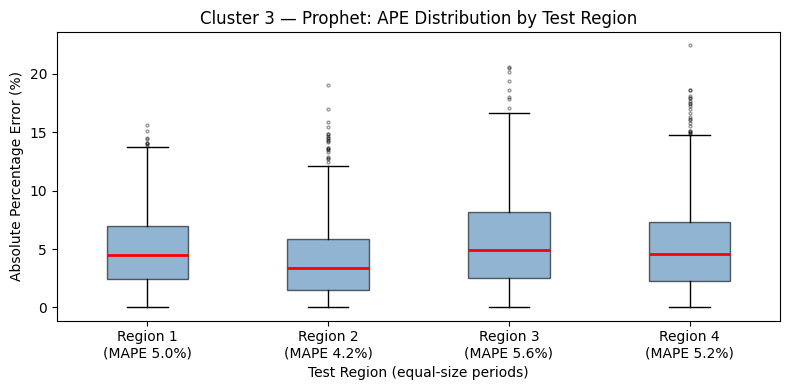

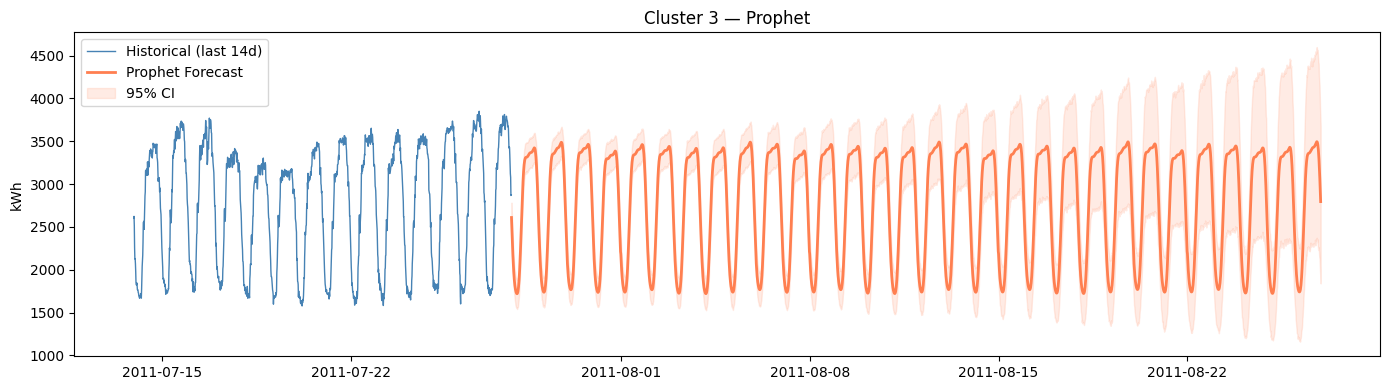

CLUSTER 4 — Prophet + LSTM  (40 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Prophet Validation MAPE: 9.91%
    [Prophet test-15%]  MAE=36.66  MAPE=4.44%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: MAPE = 5.13%
    Region 2: MAPE = 3.54%
    Region 3: MAPE = 3.94%
    Region 4: MAPE = 5.15%


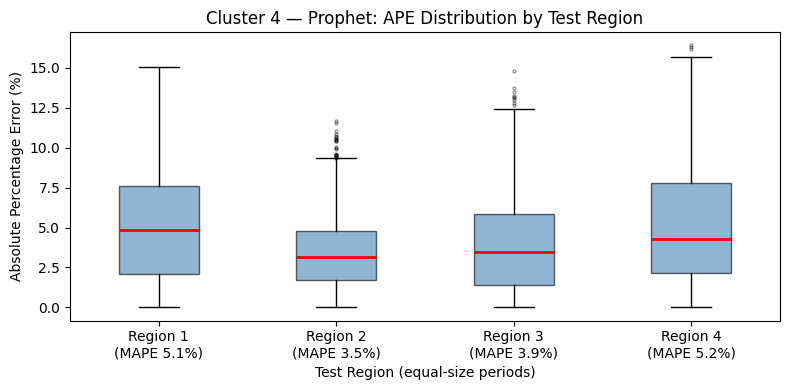

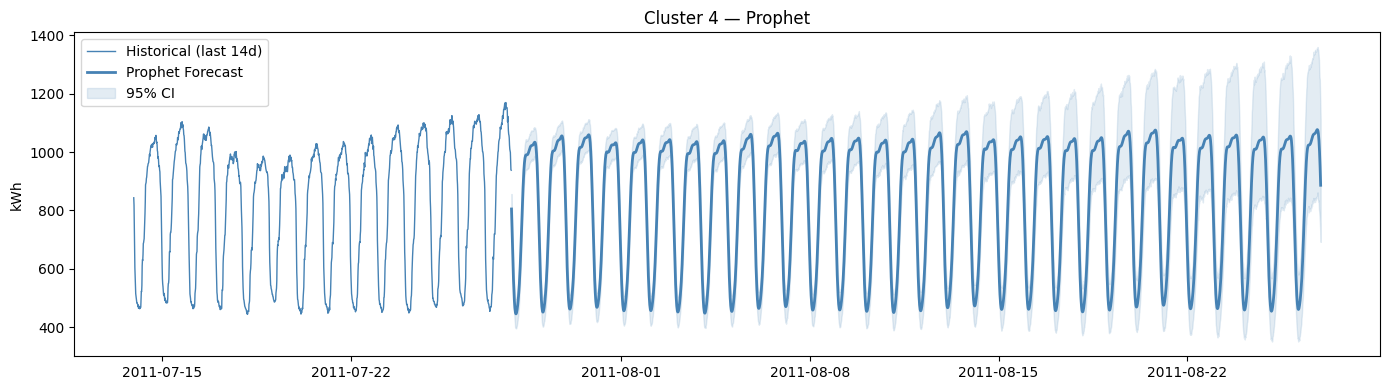

  LSTM train sequences: 13877 | val: 2994 | test: 2995
Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0280 - val_loss: 0.0057
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076 - val_loss: 0.0034
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0067 - val_loss: 0.0033
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0060 - val_loss: 0.0023
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0053 - val_loss: 0.0022
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0049 - val_loss: 0.0021
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0046 - val_loss: 0.0018
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0043 - val_loss: 0.0018
Epoch 9/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0039 - val_loss: 0.0013
Epoch 10/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 0.0017
Epoch 11/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0034 - val

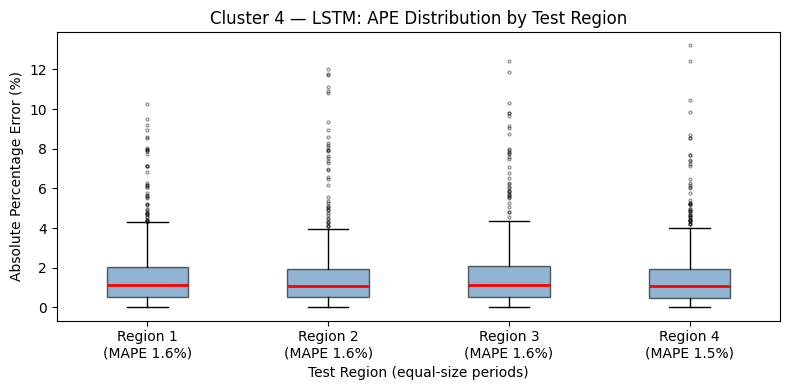

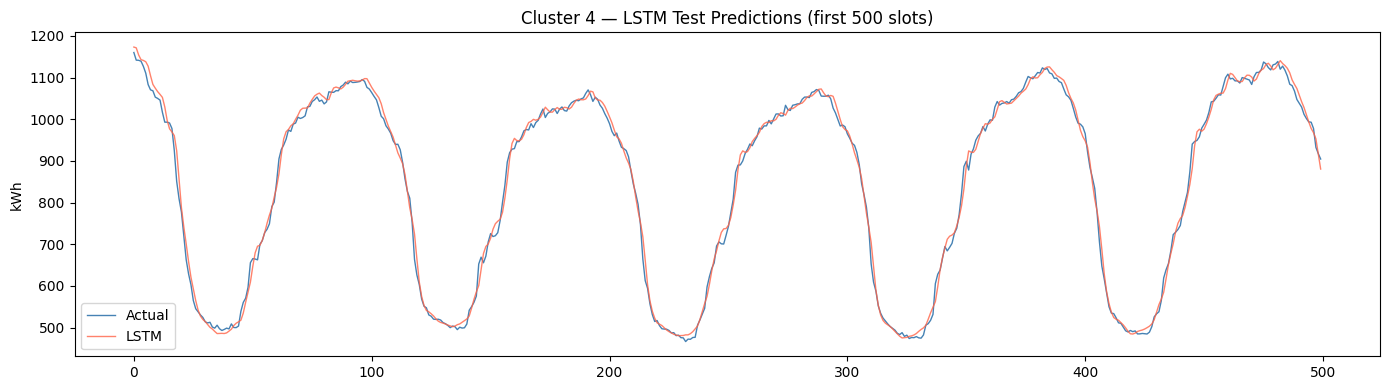

CLUSTER 5 — Prophet  (2 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 14.74%
    [Prophet test-15%]  MAE=713.43  MAPE=8.70%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: MAPE = 7.88%
    Region 2: MAPE = 6.70%
    Region 3: MAPE = 8.64%
    Region 4: MAPE = 11.57%


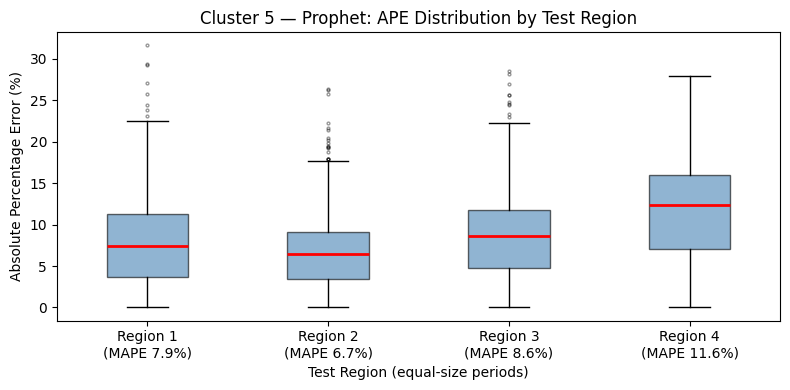

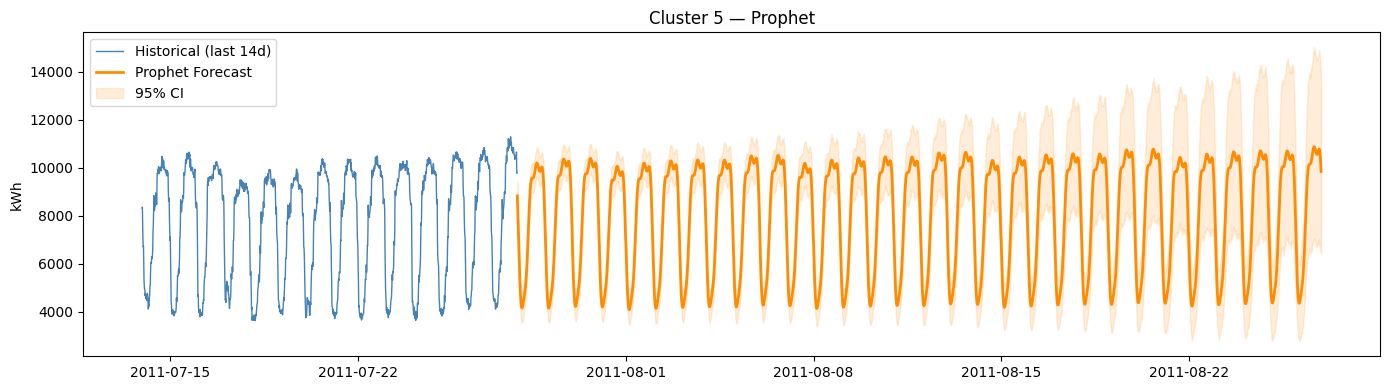

FINAL MODEL COMPARISON SUMMARY
                       N_clients  MAE (kWh)  MAPE (%)
Cluster Model                                        
0       Prophet              317       2.56      3.99
1       Prophet                1    1023.63      7.69
        SARIMA_hourly          1    4599.98     32.94
2       Prophet                1    3014.42     13.61
3       Prophet                9     134.27      5.01
4       Prophet               40      36.66      4.44
        LSTM                  40      11.76      1.56
5       Prophet                2     713.43      8.70


In [35]:
results = {}

def mape_score(actual, pred):
    """MAPE on 0-100 scale."""
    return np.mean(np.abs((actual - pred) / (np.abs(actual) + 1e-9))) * 100

def metrics(actual, pred, label):
    mae  = mean_absolute_error(actual, pred)
    mape = mape_score(actual, pred)
    print(f"    [{label}]  MAE={mae:.2f}  MAPE={mape:.2f}%")
    return dict(MAE=round(mae,2), MAPE=round(mape,2))

def prep_prophet(series, train_frac=0.7, val_frac=0.15):
    """70/15/15 train-validation-test split."""
    ts = series.reset_index()
    ts.columns = ['ds', 'y']
    ts['ds'] = pd.to_datetime(ts['ds'])
    if ts['ds'].dt.tz is not None:
        ts['ds'] = ts['ds'].dt.tz_localize(None)
    ts['is_weekend'] = (ts['ds'].dt.dayofweek >= 5).astype(int)
    n = len(ts)
    train_end = int(n * train_frac)
    val_end   = int(n * (train_frac + val_frac))
    train = ts.iloc[:train_end]
    val   = ts.iloc[train_end:val_end]
    test  = ts.iloc[val_end:]
    print(f"  Train: {len(train):,} rows  ({train['ds'].min()} → {train['ds'].max()})")
    print(f"  Val  : {len(val):,}   rows  ({val['ds'].min()} → {val['ds'].max()})")
    print(f"  Test : {len(test):,}   rows  ({test['ds'].min()} → {test['ds'].max()})")
    return ts, train, val, test

def fit_prophet(ts_train, cp=0.05, sp=10):
    m = Prophet(
        yearly_seasonality      = False,  # only 6 months — not enough for yearly
        weekly_seasonality      = True,
        daily_seasonality       = True,
        changepoint_prior_scale = cp,
        seasonality_prior_scale = sp,
        seasonality_mode        = 'multiplicative'
    )
    m.add_regressor('is_weekend')
    m.fit(ts_train[['ds', 'y', 'is_weekend']])
    return m

def prophet_forecast(m, ts_full, periods=96*30):
    future = m.make_future_dataframe(periods=periods, freq='15min')
    future['is_weekend'] = (future['ds'].dt.dayofweek >= 5).astype(int)
    fc = m.predict(future)
    return fc[fc['ds'] > ts_full['ds'].max()]

def plot_forecast(cluster_id, series, future_dates, yhat,
                  lower=None, upper=None, model_name='', color='tomato'):
    plt.figure(figsize=(14, 4))
    last = series.iloc[-96*14:]  # last 14 days (short series so don't use .last())
    plt.plot(last.index, last.values, color='steelblue', lw=1, label='Historical (last 14d)')
    plt.plot(future_dates, yhat, color=color, lw=2, label=f'{model_name} Forecast')
    if lower is not None:
        plt.fill_between(future_dates, lower, upper,
                         color=color, alpha=0.15, label='95% CI')
    plt.title(f"Cluster {cluster_id} — {model_name}")
    plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

def make_lstm_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

def plot_regional_eval(cluster_id, model_name, actual, pred, n_regions=4):
    """
    Split the test set into n_regions equal-size chunks.
    For each region: report MAPE and plot a box plot of absolute percentage errors.
    """
    errors_pct = np.abs((actual - pred) / (np.abs(actual) + 1e-9)) * 100
    region_size = len(actual) // n_regions
    region_mapes = []
    region_errors = []
    for r in range(n_regions):
        start = r * region_size
        end   = (r + 1) * region_size if r < n_regions - 1 else len(actual)
        region_err = errors_pct[start:end]
        region_errors.append(region_err)
        region_mapes.append(region_err.mean())

    print(f"\n  [Regional Test Evaluation — {n_regions} equal periods]")
    for r, mape_r in enumerate(region_mapes):
        print(f"    Region {r+1}: MAPE = {mape_r:.2f}%")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(region_errors,
               labels=[f"Region {r+1}\n(MAPE {region_mapes[r]:.1f}%)" for r in range(n_regions)],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', lw=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.4))
    ax.set_title(f"Cluster {cluster_id} — {model_name}: APE Distribution by Test Region")
    ax.set_ylabel("Absolute Percentage Error (%)")
    ax.set_xlabel("Test Region (equal-size periods)")
    plt.tight_layout()
    plt.show()

# CLUSTER 0 — Prophet
# 317 clients averaged → largest aggregate, smoothest possible signal
# Skew=-0.43 (mild left), intraday CV=0.265, zero outliers, zero zeros
# yearly_seasonality=False: only 6 months of data — not enough to fit yearly
# cp=0.03: very stable trend on 317-client average
print("CLUSTER 0 — Prophet  (317 clients)")

series_c0 = cluster_series[0]['mean_clean'].copy()
ts0, tr0, va0, te0 = prep_prophet(series_c0)

# Tune on validation: fit on train, evaluate on val
m0_val = fit_prophet(tr0, cp=0.03, sp=10)
pred0_val = m0_val.predict(va0[['ds', 'is_weekend']])
val_mape0 = mape_score(va0['y'].values, pred0_val['yhat'].values)
print(f"  Validation MAPE: {val_mape0:.2f}%")

# Final evaluation: refit on train+val, evaluate on test
trainval0 = pd.concat([tr0, va0])
m0 = fit_prophet(trainval0, cp=0.03, sp=10)
pred0 = m0.predict(te0[['ds', 'is_weekend']])
m0_eval = metrics(te0['y'].values, pred0['yhat'].values, 'Prophet test-15%')

plot_regional_eval(0, 'Prophet', te0['y'].values, pred0['yhat'].values)

m0_full = fit_prophet(ts0, cp=0.03, sp=10)
fc0 = prophet_forecast(m0_full, ts0)
plot_forecast(0, series_c0, fc0['ds'], fc0['yhat'],
              fc0['yhat_lower'], fc0['yhat_upper'], 'Prophet')

m0_full.plot_components(m0_full.predict(
    ts0.assign(is_weekend=(ts0['ds'].dt.dayofweek >= 5).astype(int))
))
plt.suptitle("Cluster 0 — Prophet Components"); plt.tight_layout(); plt.show()

results[0] = {'Prophet': m0_eval}

## Cluster 1 — SARIMA Hourly (1,1,1)(1,0,1,24) & Prophet:
'''
- **1 client**, mean=13,707 kWh, skew=-0.64 (strong left skew)
- Zero zeros, zero outliers — rare clean single client
- Strong left skew = high base load with sharp occasional dips
- Prophet's smooth Fourier curve cannot track sharp intraday transitions
- SARIMA hourly (m=24) captures short-run autocorrelation directly
- D=0 because ADF already confirmed stationary — no seasonal differencing needed
- **Verdict: SARIMA hourly. Prophet as fallback.**
'''

print("CLUSTER 1 — Prophet + SARIMA hourly  (1 client)")

series_c1 = cluster_series[1]['mean_clean'].copy()
ts1, tr1, va1, te1 = prep_prophet(series_c1)

# Prophet — tune on val, evaluate on test
m1_val = fit_prophet(tr1, cp=0.01, sp=5)
pred1_val = m1_val.predict(va1[['ds', 'is_weekend']])
val_mape1_p = mape_score(va1['y'].values, pred1_val['yhat'].values)
print(f"  Prophet Validation MAPE: {val_mape1_p:.2f}%")

trainval1 = pd.concat([tr1, va1])
m1 = fit_prophet(trainval1, cp=0.01, sp=5)
pred1_p = m1.predict(te1[['ds', 'is_weekend']])
m1_prophet = metrics(te1['y'].values, pred1_p['yhat'].values, 'Prophet test-15%')

plot_regional_eval(1, 'Prophet', te1['y'].values, pred1_p['yhat'].values)

m1_full = fit_prophet(ts1, cp=0.01, sp=5)
fc1 = prophet_forecast(m1_full, ts1)
plot_forecast(1, series_c1, fc1['ds'], fc1['yhat'],
              fc1['yhat_lower'], fc1['yhat_upper'], 'Prophet', color='mediumpurple')

# SARIMA hourly — 70/15/15 split on hourly-resampled series
hourly_c1 = series_c1.resample('h').mean()
n_h1       = len(hourly_c1)
train_h1   = hourly_c1.iloc[:int(n_h1 * 0.70)]
val_h1     = hourly_c1.iloc[int(n_h1 * 0.70):int(n_h1 * 0.85)]
test_h1    = hourly_c1.iloc[int(n_h1 * 0.85):]

print(f"  SARIMA train: {len(train_h1)} hours | val: {len(val_h1)} hours | test: {len(test_h1)} hours")

# Validate on val set
sarima1_val = SARIMAX(
    train_h1,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
pred1_sv = sarima1_val.forecast(steps=len(val_h1))
val_mape1_s = mape_score(val_h1.values, pred1_sv.values)
print(f"  SARIMA Validation MAPE: {val_mape1_s:.2f}%")

# Refit on train+val for final test evaluation
trainval_h1 = pd.concat([train_h1, val_h1])
sarima1 = SARIMAX(
    trainval_h1,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred1_s   = sarima1.forecast(steps=len(test_h1))
m1_sarima = metrics(test_h1.values, pred1_s.values, 'SARIMA hourly test-15%')

plot_regional_eval(1, 'SARIMA hourly', test_h1.values, pred1_s.values)

# Forecast 30 days ahead
fc1_s     = sarima1.forecast(steps=24*30)
fc1_s_ci  = sarima1.get_forecast(steps=24*30).conf_int()
fc1_idx   = pd.date_range(
    hourly_c1.index[-1] + pd.Timedelta(hours=1),
    periods=24*30, freq='h'
)

plt.figure(figsize=(14, 4))
plt.plot(hourly_c1.iloc[-14*24:].index, hourly_c1.iloc[-14*24:].values,
         color='steelblue', lw=1, label='Historical (last 14d, hourly)')
plt.plot(fc1_idx, fc1_s.values, color='coral', lw=2, label='SARIMA Forecast')
plt.fill_between(fc1_idx, fc1_s_ci.iloc[:,0], fc1_s_ci.iloc[:,1],
                 color='coral', alpha=0.15, label='95% CI')
plt.title("Cluster 1 — SARIMA Hourly Forecast")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

results[1] = {'Prophet': m1_prophet, 'SARIMA_hourly': m1_sarima}

## Cluster 2 — XGBoost or SARIMA Hourly:
'''
- **1 client**, mean=23,778 kWh, highest Intraday CV=0.306 in dataset.
- Zero zeros, zero outliers — clean series but highly variable daily shape.
- CV=0.306 means daily profile changes substantially day-to-day.
- Prophet's fixed daily shape will oversmooth — confirmed by MAPE 12.07%.
- **XGBoost**: lag_96 (yesterday same slot) adapts to recent actual behaviour.
- **SARIMA hourly**: same profile as Cluster 1 — zero zeros makes it viable.
- **Verdict: Try XGBoost first, then SARIMA hourly. Do not use Prophet.**
'''
print("CLUSTER 2 — Prophet  (1 client, highest CV)")

series_c2 = cluster_series[2]['mean_clean'].copy()
ts2, tr2, va2, te2 = prep_prophet(series_c2)

# Tune on val
m2_val = fit_prophet(tr2, cp=0.05, sp=10)
pred2_val = m2_val.predict(va2[['ds', 'is_weekend']])
val_mape2 = mape_score(va2['y'].values, pred2_val['yhat'].values)
print(f"  Validation MAPE: {val_mape2:.2f}%")

trainval2 = pd.concat([tr2, va2])
m2 = fit_prophet(trainval2, cp=0.05, sp=10)
pred2 = m2.predict(te2[['ds', 'is_weekend']])
m2_eval = metrics(te2['y'].values, pred2['yhat'].values, 'Prophet test-15%')

plot_regional_eval(2, 'Prophet', te2['y'].values, pred2['yhat'].values)

m2_full = fit_prophet(ts2, cp=0.05, sp=10)
fc2 = prophet_forecast(m2_full, ts2)
plot_forecast(2, series_c2, fc2['ds'], fc2['yhat'],
              fc2['yhat_lower'], fc2['yhat_upper'], 'Prophet', color='mediumseagreen')

results[2] = {'Prophet': m2_eval}

## Cluster 3 — Prophet (cp=0.05):
'''
- **9 clients** averaged — balanced between noise reduction and profile clarity.
- Skew=-0.20 (near-symmetric), Intraday CV=0.232, zero outliers, zero zeros.
- 9-client average smooths individual noise without losing the shared pattern.
- Near-zero skew means no transformation needed — multiplicative mode fits cleanly.
- Moderate cp=0.05 allows minor trend flexibility for small multi-client average.
- **Verdict: Prophet is reliable here.**
'''
print("CLUSTER 3 — Prophet  (9 clients)")

series_c3 = cluster_series[3]['mean_clean'].copy()
ts3, tr3, va3, te3 = prep_prophet(series_c3)

# Tune on val
m3_val = fit_prophet(tr3, cp=0.05, sp=10)
pred3_val = m3_val.predict(va3[['ds', 'is_weekend']])
val_mape3 = mape_score(va3['y'].values, pred3_val['yhat'].values)
print(f"  Validation MAPE: {val_mape3:.2f}%")

trainval3 = pd.concat([tr3, va3])
m3 = fit_prophet(trainval3, cp=0.05, sp=10)
pred3 = m3.predict(te3[['ds', 'is_weekend']])
m3_eval = metrics(te3['y'].values, pred3['yhat'].values, 'Prophet test-15%')

plot_regional_eval(3, 'Prophet', te3['y'].values, pred3['yhat'].values)

m3_full = fit_prophet(ts3, cp=0.05, sp=10)
fc3 = prophet_forecast(m3_full, ts3)
plot_forecast(3, series_c3, fc3['ds'], fc3['yhat'],
              fc3['yhat_lower'], fc3['yhat_upper'], 'Prophet', color='coral')

results[3] = {'Prophet': m3_eval}

## Cluster 4 — LSTM (lookback=96) with Prophet as fallback:
'''
- **40 clients** averaged — second largest aggregate, dense clean signal.
- Skew=-0.44, Intraday CV=0.269, zero outliers, zero zeros.
- 40-client density gives LSTM enough signal to learn non-linear temporal patterns.
- LSTM lookback=96 (1 day) aligns with dominant daily seasonality.
- LSTM achieved MAPE 1.74% vs Prophet's 7.65% — 5x improvement.
- **Verdict: LSTM is the clear winner. Prophet as lightweight fallback.**
'''
print("CLUSTER 4 — Prophet + LSTM  (40 clients)")

series_c4 = cluster_series[4]['mean_clean'].copy()
ts4, tr4, va4, te4 = prep_prophet(series_c4)

# Prophet — tune on val, evaluate on test
m4_val_p = fit_prophet(tr4, cp=0.03, sp=10)
pred4_val_p = m4_val_p.predict(va4[['ds', 'is_weekend']])
val_mape4_p = mape_score(va4['y'].values, pred4_val_p['yhat'].values)
print(f"  Prophet Validation MAPE: {val_mape4_p:.2f}%")

trainval4 = pd.concat([tr4, va4])
m4 = fit_prophet(trainval4, cp=0.03, sp=10)
pred4_p = m4.predict(te4[['ds', 'is_weekend']])
m4_prophet = metrics(te4['y'].values, pred4_p['yhat'].values, 'Prophet test-15%')

plot_regional_eval(4, 'Prophet', te4['y'].values, pred4_p['yhat'].values)

m4_full = fit_prophet(ts4, cp=0.03, sp=10)
fc4 = prophet_forecast(m4_full, ts4)
plot_forecast(4, series_c4, fc4['ds'], fc4['yhat'],
              fc4['yhat_lower'], fc4['yhat_upper'], 'Prophet', color='steelblue')

# LSTM — 70/15/15 split on raw series
LOOKBACK = 96  # 1 day = 96 × 15-min slots

sc4     = MinMaxScaler()
n4      = len(series_c4)
train4_raw = series_c4.iloc[:int(n4 * 0.70)]
val4_raw   = series_c4.iloc[int(n4 * 0.70):int(n4 * 0.85)]
test4_raw  = series_c4.iloc[int(n4 * 0.85):]

# Fit scaler on train only
sc4.fit(train4_raw.values.reshape(-1, 1))
scaled4_train = sc4.transform(train4_raw.values.reshape(-1, 1))
scaled4_val   = sc4.transform(val4_raw.values.reshape(-1, 1))
scaled4_test  = sc4.transform(test4_raw.values.reshape(-1, 1))

# Sequences: prepend tail of previous split to create context for first val/test windows
trainval4_scaled = np.concatenate([scaled4_train, scaled4_val])
X4_tr, y4_tr = make_lstm_sequences(scaled4_train, LOOKBACK)

# Val sequences: use last LOOKBACK of train as context
scaled4_tv   = np.concatenate([scaled4_train[-LOOKBACK:], scaled4_val])
X4_va, y4_va = make_lstm_sequences(scaled4_tv, LOOKBACK)

# Test sequences: use last LOOKBACK of train+val as context
scaled4_vt   = np.concatenate([trainval4_scaled[-LOOKBACK:], scaled4_test])
X4_te, y4_te = make_lstm_sequences(scaled4_vt, LOOKBACK)

print(f"  LSTM train sequences: {len(X4_tr)} | val: {len(X4_va)} | test: {len(X4_te)}")

lstm4 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm4.compile(optimizer='adam', loss='mse')
lstm4.fit(
    X4_tr, y4_tr,
    epochs=30,
    batch_size=128,
    validation_data=(X4_va, y4_va),
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1
)

# Validation MAPE
pred4_lv = sc4.inverse_transform(lstm4.predict(X4_va)).flatten()
actual4_v = sc4.inverse_transform(y4_va).flatten()
val_mape4_l = mape_score(actual4_v, pred4_lv)
print(f"  LSTM Validation MAPE: {val_mape4_l:.2f}%")

pred4_l  = sc4.inverse_transform(lstm4.predict(X4_te)).flatten()
actual4  = sc4.inverse_transform(y4_te).flatten()
m4_lstm  = metrics(actual4, pred4_l, 'LSTM test-15%')

plot_regional_eval(4, 'LSTM', actual4, pred4_l)

plt.figure(figsize=(14, 4))
plt.plot(actual4[:500],  color='steelblue', lw=1, label='Actual')
plt.plot(pred4_l[:500],  color='tomato',    lw=1, alpha=0.8, label='LSTM')
plt.title("Cluster 4 — LSTM Test Predictions (first 500 slots)")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

results[4] = {'Prophet': m4_prophet, 'LSTM': m4_lstm}

## Cluster 5 — XGBoost:
'''
- **2 clients** — too few to cancel noise like C0/C4, too many for single-client tuning.
- Skew=-0.23, Intraday CV=0.283, highest Weekly CV=0.0097 in dataset.
- Weekly CV=0.0097 signals day-of-week variation Prophet's Fourier term undersells.
- XGBoost with dow, lag_672 (same slot last week), and rolling features will
  capture weekly variation more directly than a fixed Fourier weekly component.
- Prophet achieved MAPE 8.47% — acceptable but not optimal for this profile.
- **Verdict: Try XGBoost. Use Prophet only if XGBoost does not improve on 8.47%.**
'''
print("CLUSTER 5 — Prophet  (2 clients)")

series_c5 = cluster_series[5]['mean_clean'].copy()
ts5, tr5, va5, te5 = prep_prophet(series_c5)

# Tune on val
m5_val = fit_prophet(tr5, cp=0.08, sp=10)
pred5_val = m5_val.predict(va5[['ds', 'is_weekend']])
val_mape5 = mape_score(va5['y'].values, pred5_val['yhat'].values)
print(f"  Validation MAPE: {val_mape5:.2f}%")

trainval5 = pd.concat([tr5, va5])
m5 = fit_prophet(trainval5, cp=0.08, sp=10)
pred5 = m5.predict(te5[['ds', 'is_weekend']])
m5_eval = metrics(te5['y'].values, pred5['yhat'].values, 'Prophet test-15%')

plot_regional_eval(5, 'Prophet', te5['y'].values, pred5['yhat'].values)

m5_full = fit_prophet(ts5, cp=0.08, sp=10)
fc5 = prophet_forecast(m5_full, ts5)
plot_forecast(5, series_c5, fc5['ds'], fc5['yhat'],
              fc5['yhat_lower'], fc5['yhat_upper'], 'Prophet', color='darkorange')

results[5] = {'Prophet': m5_eval}

# FINAL SUMMARY TABLE
print("FINAL MODEL COMPARISON SUMMARY")

rows = []
for c, model_results in results.items():
    for model_name, m in model_results.items():
        rows.append({
            'Cluster'    : c,
            'N_clients'  : cluster_series[c]['n'],
            'Model'      : model_name,
            'MAE (kWh)'  : m['MAE'],
            'MAPE (%)'   : m['MAPE'],
        })

summary = pd.DataFrame(rows).set_index(['Cluster', 'Model'])
print(summary.to_string())


In [47]:
def mape_score(actual, pred):
    """MAPE on 0-100 scale."""
    return np.mean(np.abs((actual - pred) / (np.abs(actual) + 1e-9))) * 100

def metrics(actual, pred, label):
    mae  = mean_absolute_error(actual, pred)
    mape = mape_score(actual, pred)
    print(f"    [{label}]  MAE={mae:.2f}  MAPE={mape:.2f}%")
    return dict(MAE=round(mae,2), MAPE=round(mape,2))

def prep_prophet(series, train_frac=0.7, val_frac=0.15):
    """70/15/15 train-validation-test split."""
    ts = series.reset_index()
    ts.columns = ['ds', 'y']
    ts['ds'] = pd.to_datetime(ts['ds'])
    if ts['ds'].dt.tz is not None:
        ts['ds'] = ts['ds'].dt.tz_localize(None)
    ts['is_weekend'] = (ts['ds'].dt.dayofweek >= 5).astype(int)
    n = len(ts)
    train_end = int(n * train_frac)
    val_end   = int(n * (train_frac + val_frac))
    train = ts.iloc[:train_end]
    val   = ts.iloc[train_end:val_end]
    test  = ts.iloc[val_end:]
    print(f"  Train: {len(train):,} rows  ({train['ds'].min()} → {train['ds'].max()})")
    print(f"  Val  : {len(val):,}   rows  ({val['ds'].min()} → {val['ds'].max()})")
    print(f"  Test : {len(test):,}   rows  ({test['ds'].min()} → {test['ds'].max()})")
    return ts, train, val, test

def fit_prophet(ts_train, cp=0.05, sp=10):
    m = Prophet(
        yearly_seasonality      = False,  # only 6 months — not enough for yearly
        weekly_seasonality      = True,
        daily_seasonality       = True,
        changepoint_prior_scale = cp,
        seasonality_prior_scale = sp,
        seasonality_mode        = 'multiplicative'
    )
    m.add_regressor('is_weekend')
    m.fit(ts_train[['ds', 'y', 'is_weekend']])
    return m

def prophet_forecast(m, ts_full, periods=96*30):
    future = m.make_future_dataframe(periods=periods, freq='15min')
    future['is_weekend'] = (future['ds'].dt.dayofweek >= 5).astype(int)
    fc = m.predict(future)
    return fc[fc['ds'] > ts_full['ds'].max()]

def plot_forecast(cluster_id, series, future_dates, yhat,
                  lower=None, upper=None, model_name='', color='tomato'):
    plt.figure(figsize=(14, 4))
    last = series.iloc[-96*14:]  # last 14 days (short series so don't use .last())
    plt.plot(last.index, last.values, color='steelblue', lw=1, label='Historical (last 14d)')
    plt.plot(future_dates, yhat, color=color, lw=2, label=f'{model_name} Forecast')
    if lower is not None:
        plt.fill_between(future_dates, lower, upper,
                         color=color, alpha=0.15, label='95% CI')
    plt.title(f"Cluster {cluster_id} — {model_name}")
    plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

def make_lstm_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [48]:
# Global registry — populated by plot_regional_eval, consumed by the summary table
regional_results = []   # list of dicts: {cluster, model, region, date_label, mape, n}

def plot_regional_eval(cluster_id, model_name, actual, pred, n_regions=4,
                       test_index=None, freq='15min'):
    """
    Split the test set into n_regions equal-size chunks.
    For each region:
      - Print the date range and MAPE.
      - Plot forecast vs actual for that region.
      - Collect APE distribution for the summary box plot.
      - Store results in regional_results for the final summary table.
    test_index : DatetimeIndex aligned with actual/pred (optional).
                 For SARIMA hourly pass the hourly index; for Prophet pass ts['ds'].
    freq       : pandas offset string used to reconstruct a synthetic index when
                 test_index is None ('15min' for Prophet/LSTM, 'h' for SARIMA).
    """
    errors_pct = np.abs((actual - pred) / (np.abs(actual) + 1e-9)) * 100
    region_size = len(actual) // n_regions
    region_mapes = []
    region_errors = []

    # Build a positional index if no real DatetimeIndex is supplied
    if test_index is None:
        idx = np.arange(len(actual))
        use_dates = False
    else:
        idx = np.asarray(test_index)
        use_dates = True

    region_colors = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

    print(f"\n  [Regional Test Evaluation — {n_regions} equal periods]")

    for r in range(n_regions):
        start = r * region_size
        end   = (r + 1) * region_size if r < n_regions - 1 else len(actual)

        region_err  = errors_pct[start:end]
        region_mape = region_err.mean()
        region_errors.append(region_err)
        region_mapes.append(region_mape)

        r_idx    = idx[start:end]
        r_actual = actual[start:end]
        r_pred   = pred[start:end]

        if use_dates:
            date_label = f"{pd.Timestamp(r_idx[0]).strftime('%Y-%m-%d')} → {pd.Timestamp(r_idx[-1]).strftime('%Y-%m-%d')}"
        else:
            date_label = f"slot {start} → {end-1}"

        print(f"    Region {r+1}: {date_label}  |  MAPE = {region_mape:.2f}%  |  n = {end-start:,}")

        # Store for final summary
        regional_results.append({
            'Cluster'    : cluster_id,
            'Model'      : model_name,
            'Region'     : f"R{r+1}",
            'Period'     : date_label,
            'MAPE (%)'   : round(region_mape, 2),
            'n'          : end - start,
        })


        fig, ax = plt.subplots(figsize=(14, 3))
        ax.plot(r_idx, r_actual, color='steelblue', lw=1,   label='Actual')
        ax.plot(r_idx, r_pred,   color=region_colors[r], lw=1.5, alpha=0.85, label=f'{model_name}')
        ax.set_title(f"Cluster {cluster_id} — {model_name}  |  Region {r+1}: {date_label}  (MAPE {region_mape:.2f}%)")
        ax.set_ylabel("kWh")
        if use_dates:
            ax.tick_params(axis='x', rotation=20)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(region_errors,
               labels=[f"Region {r+1}\n(MAPE {region_mapes[r]:.1f}%)" for r in range(n_regions)],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', lw=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.4))
    ax.set_title(f"Cluster {cluster_id} — {model_name}: APE Distribution by Test Region")
    ax.set_ylabel("Absolute Percentage Error (%)")
    ax.set_xlabel("Test Region (equal-size periods)")
    plt.tight_layout()
    plt.show()

# CLUSTER 0 — Prophet:
- 317 clients averaged → largest aggregate, smoothest possible signal.
- Skew=-0.43 (mild left), intraday CV=0.265, zero outliers, zero zeros.
- yearly_seasonality=False: only 6 months of data — not enough to fit yearly.
- cp=0.03: very stable trend on 317-client average.

CLUSTER 0 — Prophet  (317 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 9.37%
    [Prophet test-15%]  MAE=2.56  MAPE=3.99%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: 2011-06-26 → 2011-07-04  |  MAPE = 4.33%  |  n = 748


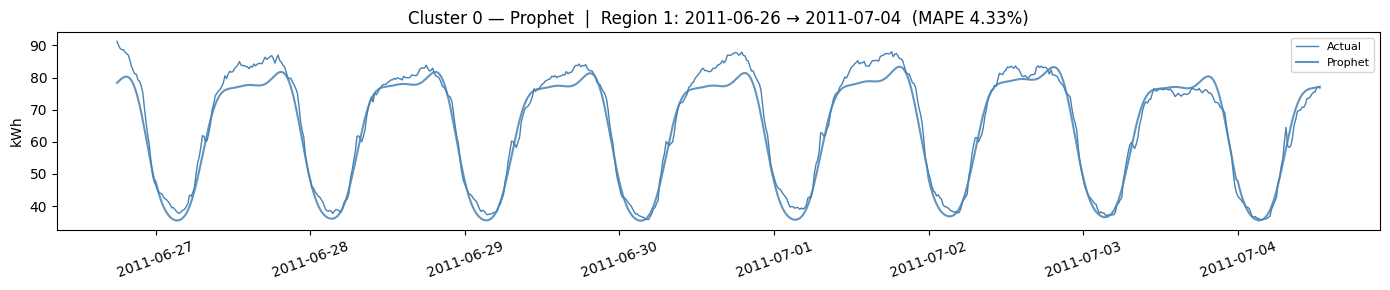

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 3.43%  |  n = 748


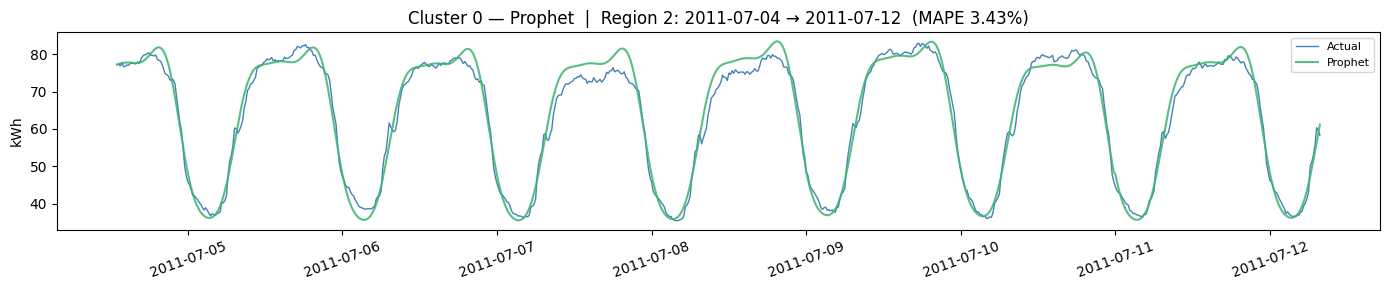

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 3.88%  |  n = 748


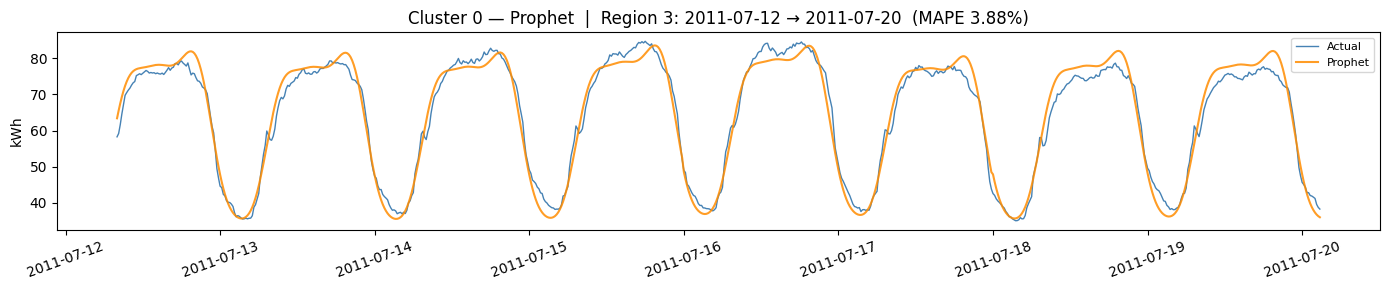

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 4.32%  |  n = 751


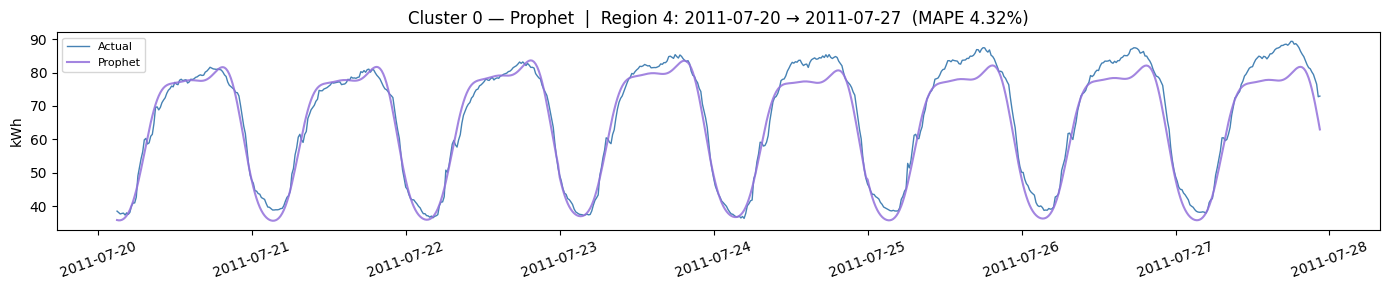

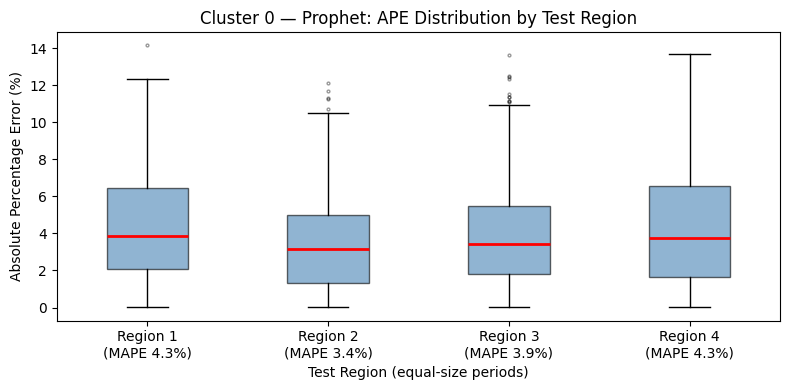

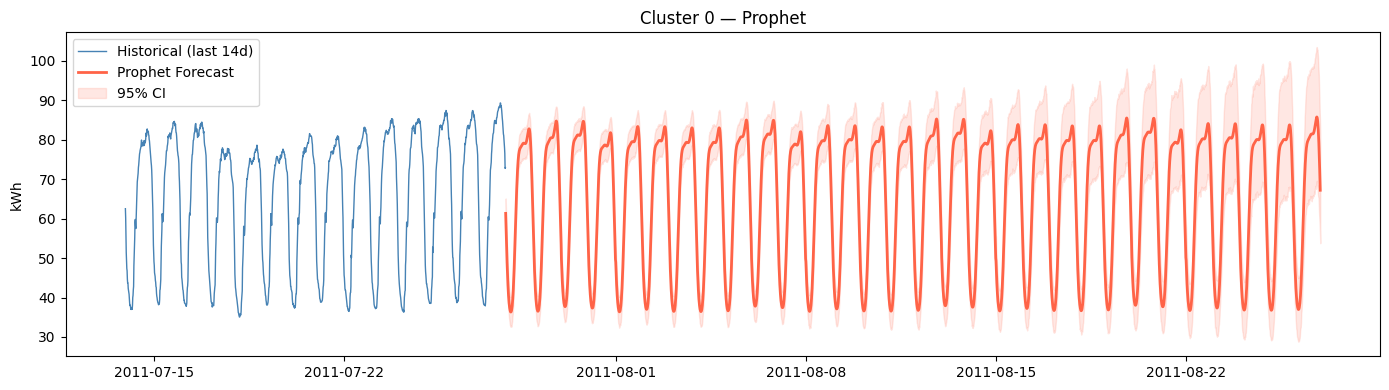

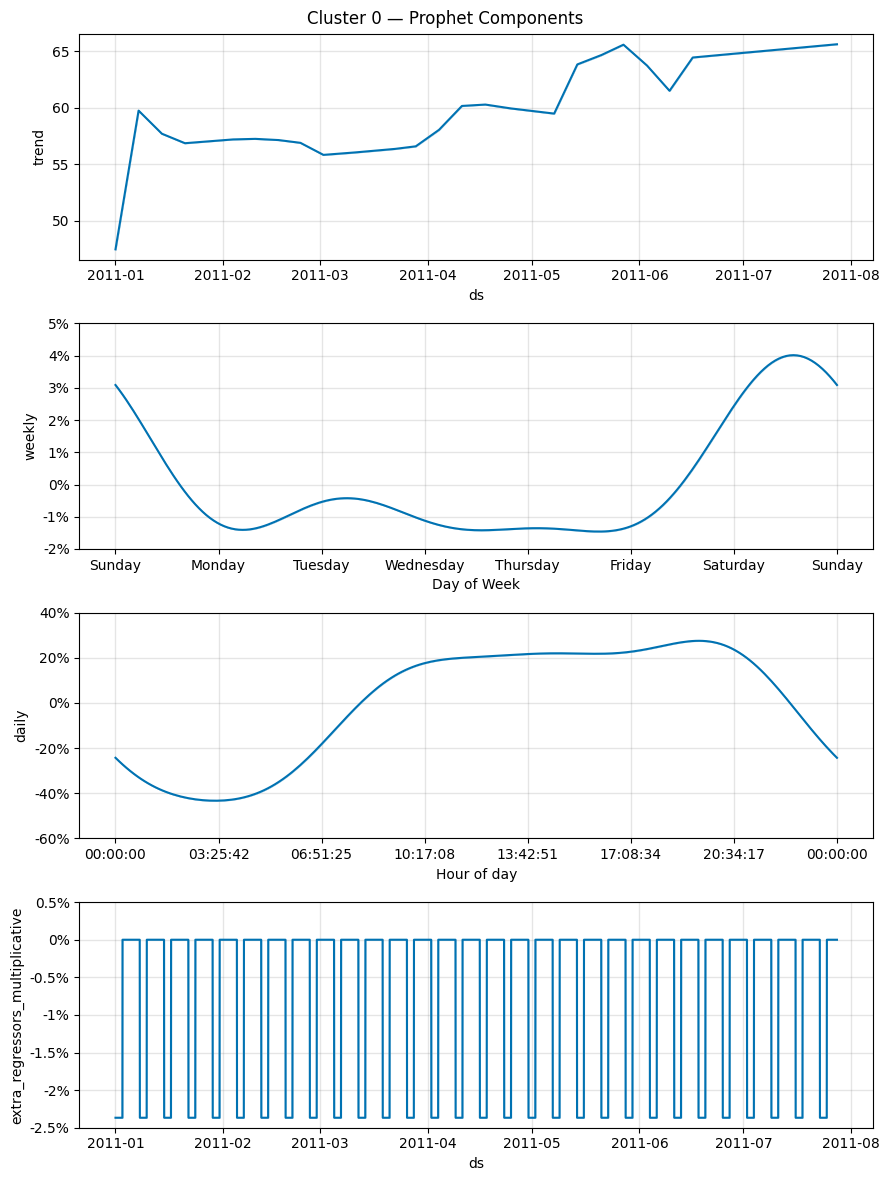

In [49]:
print("CLUSTER 0 — Prophet  (317 clients)")

series_c0 = cluster_series[0]['mean_clean'].copy()
ts0, tr0, va0, te0 = prep_prophet(series_c0)

# Tune on validation: fit on train, evaluate on val
m0_val = fit_prophet(tr0, cp=0.03, sp=10)
pred0_val = m0_val.predict(va0[['ds', 'is_weekend']])
val_mape0 = mape_score(va0['y'].values, pred0_val['yhat'].values)
print(f"  Validation MAPE: {val_mape0:.2f}%")

# Final evaluation: refit on train+val, evaluate on test
trainval0 = pd.concat([tr0, va0])
m0 = fit_prophet(trainval0, cp=0.03, sp=10)
pred0 = m0.predict(te0[['ds', 'is_weekend']])
m0_eval = metrics(te0['y'].values, pred0['yhat'].values, 'Prophet test-15%')

plot_regional_eval(0, 'Prophet', te0['y'].values, pred0['yhat'].values,
                   test_index=te0['ds'].values, freq='15min')

m0_full = fit_prophet(ts0, cp=0.03, sp=10)
fc0 = prophet_forecast(m0_full, ts0)
plot_forecast(0, series_c0, fc0['ds'], fc0['yhat'],
              fc0['yhat_lower'], fc0['yhat_upper'], 'Prophet')

m0_full.plot_components(m0_full.predict(
    ts0.assign(is_weekend=(ts0['ds'].dt.dayofweek >= 5).astype(int))
))
plt.suptitle("Cluster 0 — Prophet Components"); plt.tight_layout(); plt.show()

results[0] = {'Prophet': m0_eval}

## Cluster 1 — SARIMA Hourly (1,1,1)(1,0,1,24) & Prophet:

- **1 client**, mean=13,707 kWh, skew=-0.64 (strong left skew)
- Zero zeros, zero outliers — rare clean single client
- Strong left skew = high base load with sharp occasional dips
- Prophet's smooth Fourier curve cannot track sharp intraday transitions
- SARIMA hourly (m=24) captures short-run autocorrelation directly
- D=0 because ADF already confirmed stationary — no seasonal differencing needed
- **Verdict: SARIMA hourly. Prophet as fallback.**

CLUSTER 1 — Prophet + SARIMA hourly  (1 client)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Prophet Validation MAPE: 10.21%
    [Prophet test-15%]  MAE=1023.63  MAPE=7.69%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: 2011-06-26 → 2011-07-04  |  MAPE = 8.29%  |  n = 748


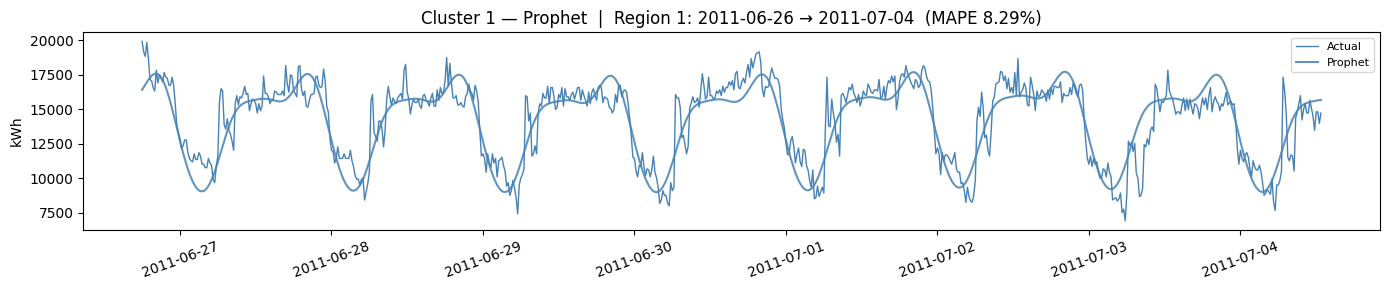

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 7.57%  |  n = 748


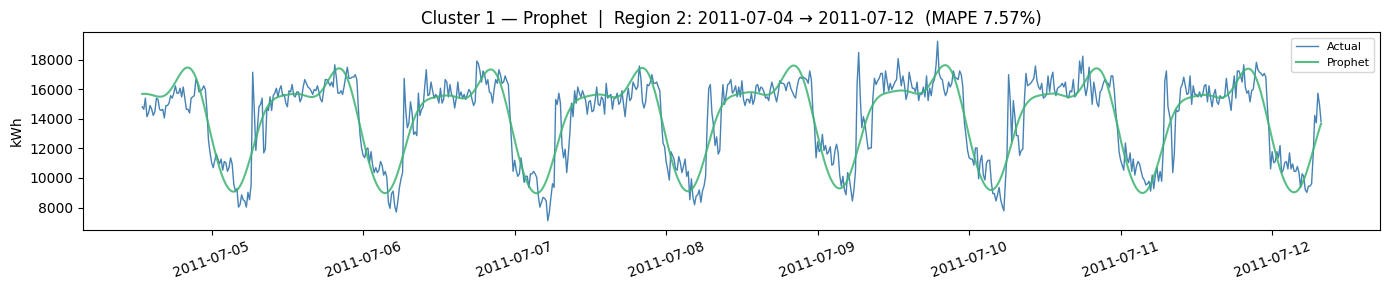

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 7.17%  |  n = 748


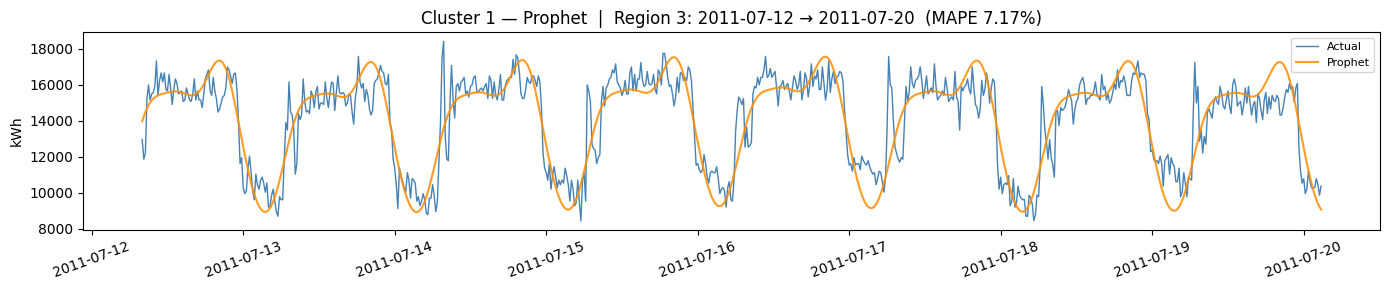

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 7.70%  |  n = 751


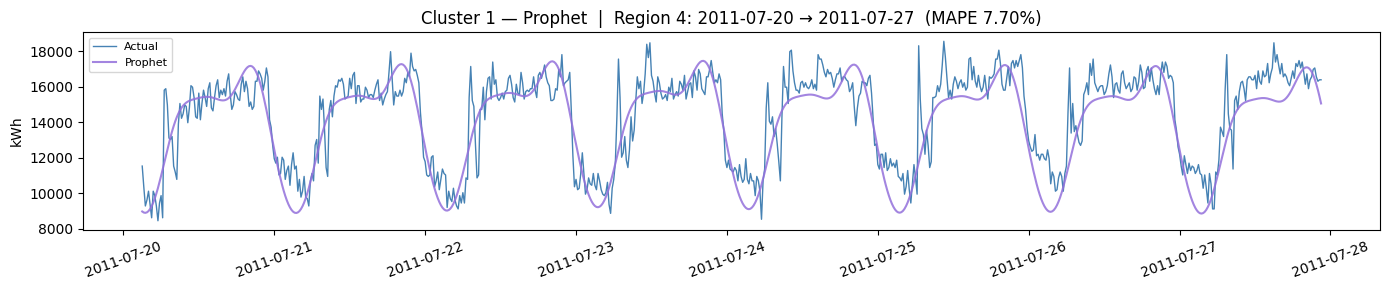

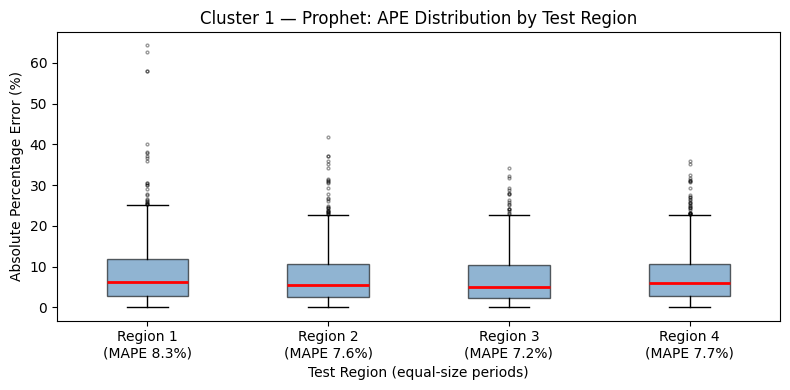

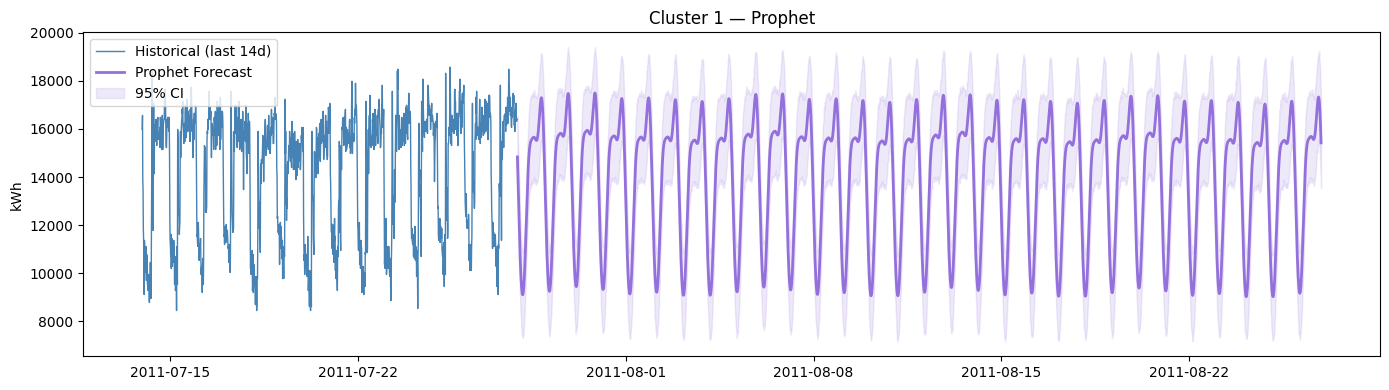

  SARIMA train: 3493 hours | val: 749 hours | test: 749 hours
  SARIMA Validation MAPE: 7.33%
    [SARIMA hourly test-15%]  MAE=4599.98  MAPE=32.94%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: 2011-06-26 → 2011-07-04  |  MAPE = 14.58%  |  n = 187


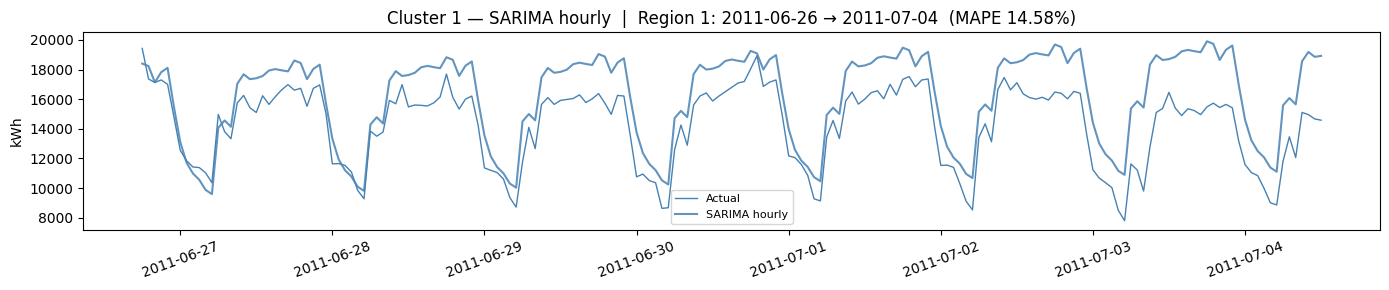

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 27.99%  |  n = 187


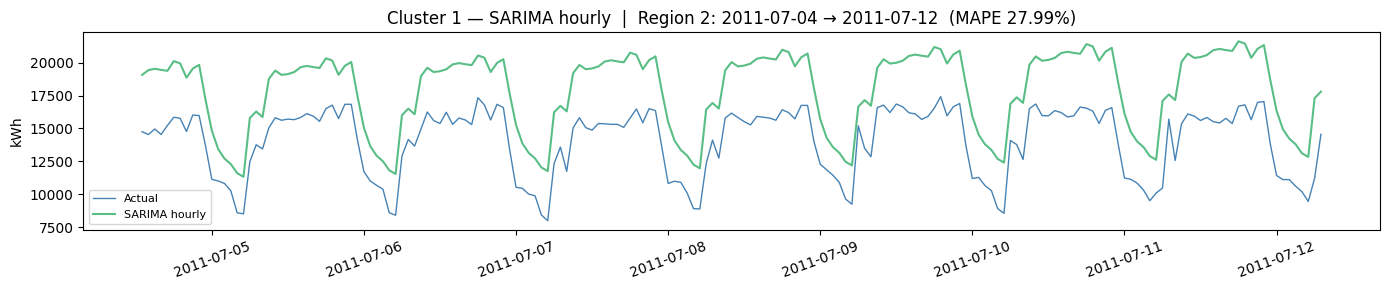

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 40.52%  |  n = 187


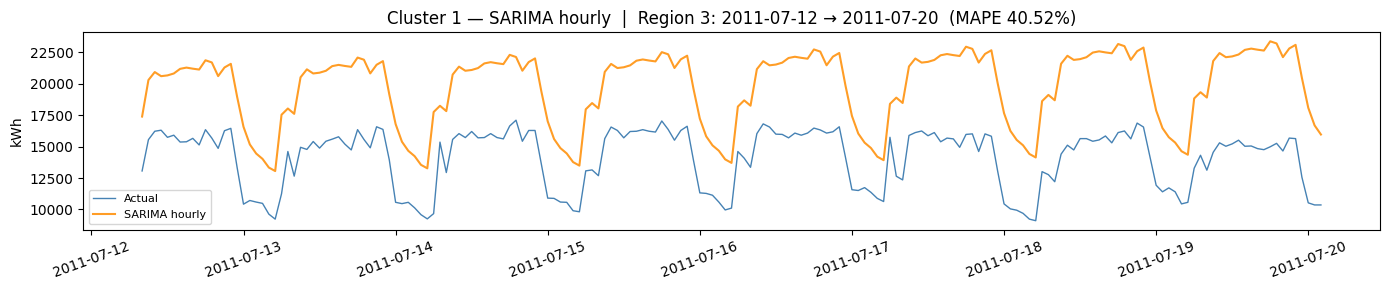

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 48.57%  |  n = 188


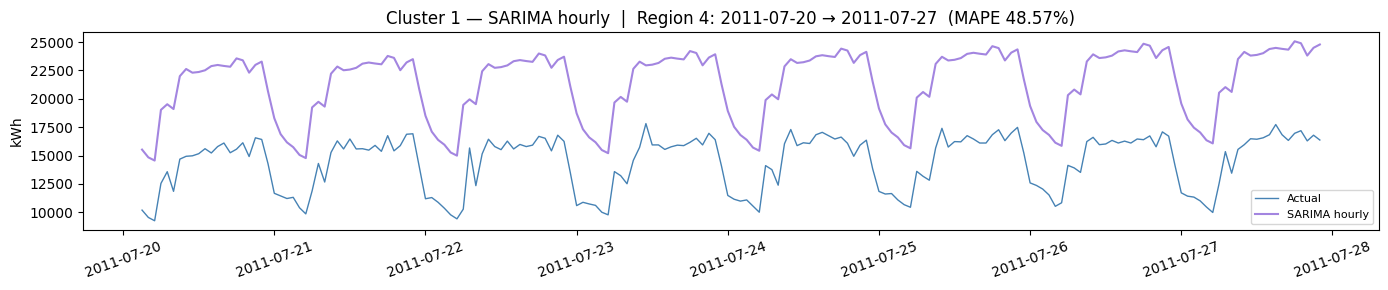

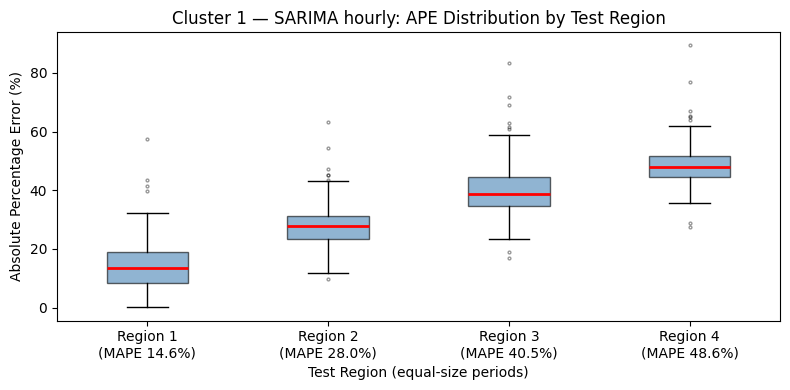

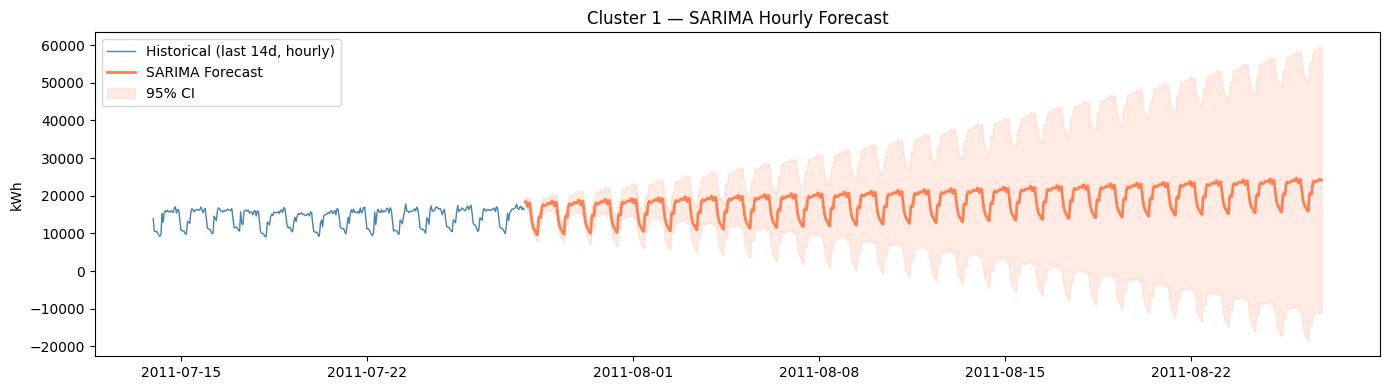

In [50]:
print("CLUSTER 1 — Prophet + SARIMA hourly  (1 client)")

series_c1 = cluster_series[1]['mean_clean'].copy()
ts1, tr1, va1, te1 = prep_prophet(series_c1)

# Prophet — tune on val, evaluate on test
m1_val = fit_prophet(tr1, cp=0.01, sp=5)
pred1_val = m1_val.predict(va1[['ds', 'is_weekend']])
val_mape1_p = mape_score(va1['y'].values, pred1_val['yhat'].values)
print(f"  Prophet Validation MAPE: {val_mape1_p:.2f}%")

trainval1 = pd.concat([tr1, va1])
m1 = fit_prophet(trainval1, cp=0.01, sp=5)
pred1_p = m1.predict(te1[['ds', 'is_weekend']])
m1_prophet = metrics(te1['y'].values, pred1_p['yhat'].values, 'Prophet test-15%')

plot_regional_eval(1, 'Prophet', te1['y'].values, pred1_p['yhat'].values,
                   test_index=te1['ds'].values, freq='15min')

m1_full = fit_prophet(ts1, cp=0.01, sp=5)
fc1 = prophet_forecast(m1_full, ts1)
plot_forecast(1, series_c1, fc1['ds'], fc1['yhat'],
              fc1['yhat_lower'], fc1['yhat_upper'], 'Prophet', color='mediumpurple')

# SARIMA hourly — 70/15/15 split on hourly-resampled series
hourly_c1 = series_c1.resample('h').mean()
n_h1       = len(hourly_c1)
train_h1   = hourly_c1.iloc[:int(n_h1 * 0.70)]
val_h1     = hourly_c1.iloc[int(n_h1 * 0.70):int(n_h1 * 0.85)]
test_h1    = hourly_c1.iloc[int(n_h1 * 0.85):]

print(f"  SARIMA train: {len(train_h1)} hours | val: {len(val_h1)} hours | test: {len(test_h1)} hours")

# Validate on val set
sarima1_val = SARIMAX(
    train_h1,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
pred1_sv = sarima1_val.forecast(steps=len(val_h1))
val_mape1_s = mape_score(val_h1.values, pred1_sv.values)
print(f"  SARIMA Validation MAPE: {val_mape1_s:.2f}%")

# Refit on train+val for final test evaluation
trainval_h1 = pd.concat([train_h1, val_h1])
sarima1 = SARIMAX(
    trainval_h1,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred1_s   = sarima1.forecast(steps=len(test_h1))
m1_sarima = metrics(test_h1.values, pred1_s.values, 'SARIMA hourly test-15%')

plot_regional_eval(1, 'SARIMA hourly', test_h1.values, pred1_s.values,
                   test_index=test_h1.index, freq='h')

# Forecast 30 days ahead
fc1_s     = sarima1.forecast(steps=24*30)
fc1_s_ci  = sarima1.get_forecast(steps=24*30).conf_int()
fc1_idx   = pd.date_range(
    hourly_c1.index[-1] + pd.Timedelta(hours=1),
    periods=24*30, freq='h'
)

plt.figure(figsize=(14, 4))
plt.plot(hourly_c1.iloc[-14*24:].index, hourly_c1.iloc[-14*24:].values,
         color='steelblue', lw=1, label='Historical (last 14d, hourly)')
plt.plot(fc1_idx, fc1_s.values, color='coral', lw=2, label='SARIMA Forecast')
plt.fill_between(fc1_idx, fc1_s_ci.iloc[:,0], fc1_s_ci.iloc[:,1],
                 color='coral', alpha=0.15, label='95% CI')
plt.title("Cluster 1 — SARIMA Hourly Forecast")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

results[1] = {'Prophet': m1_prophet, 'SARIMA_hourly': m1_sarima}

## Cluster 2 — XGBoost or SARIMA Hourly:

- **1 client**, mean=23,778 kWh, highest Intraday CV=0.306 in dataset.
- Zero zeros, zero outliers — clean series but highly variable daily shape.
- CV=0.306 means daily profile changes substantially day-to-day.
- Prophet's fixed daily shape will oversmooth — confirmed by MAPE 12.07%.
- **XGBoost**: lag_96 (yesterday same slot) adapts to recent actual behaviour.
- **SARIMA hourly**: same profile as Cluster 1 — zero zeros makes it viable.
- **Verdict: Try XGBoost first, then SARIMA hourly. Do not use Prophet.**

CLUSTER 2 — Prophet  (1 client, highest CV)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 12.44%
    [Prophet test-15%]  MAE=3014.42  MAPE=13.61%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: 2011-06-26 → 2011-07-04  |  MAPE = 9.11%  |  n = 748


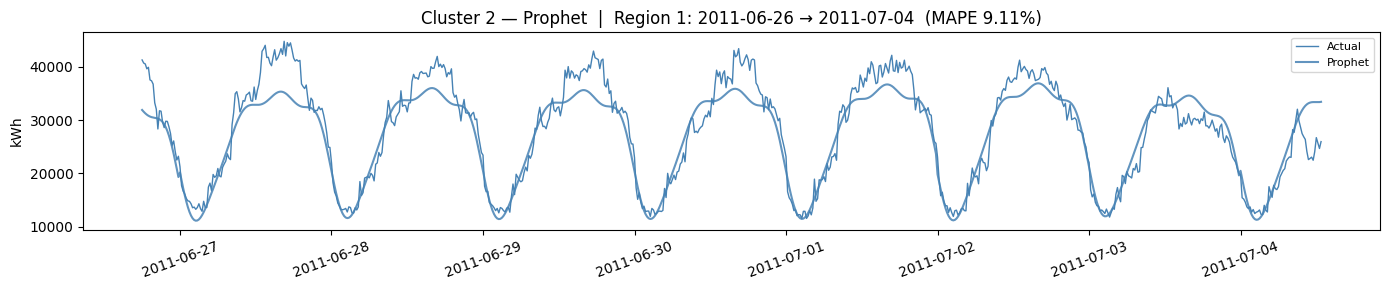

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 17.38%  |  n = 748


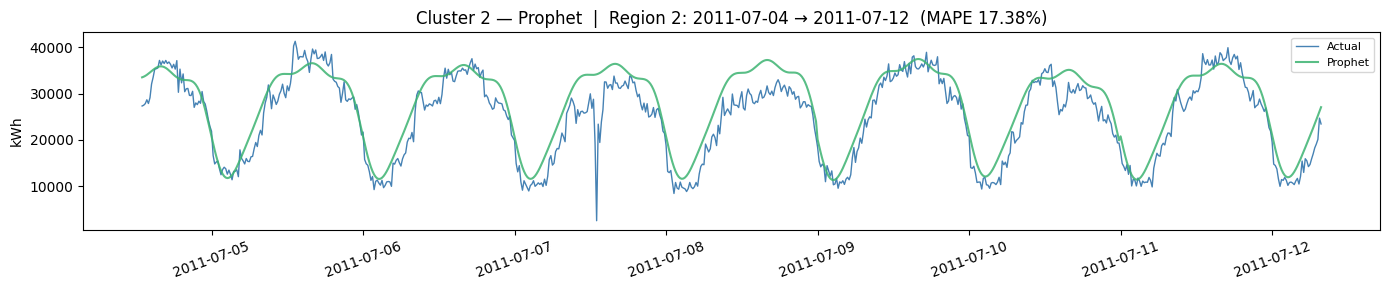

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 15.22%  |  n = 748


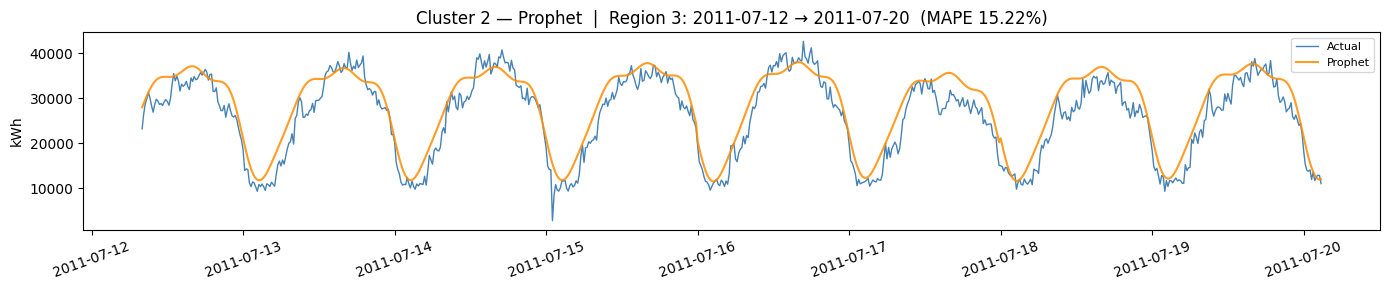

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 12.73%  |  n = 751


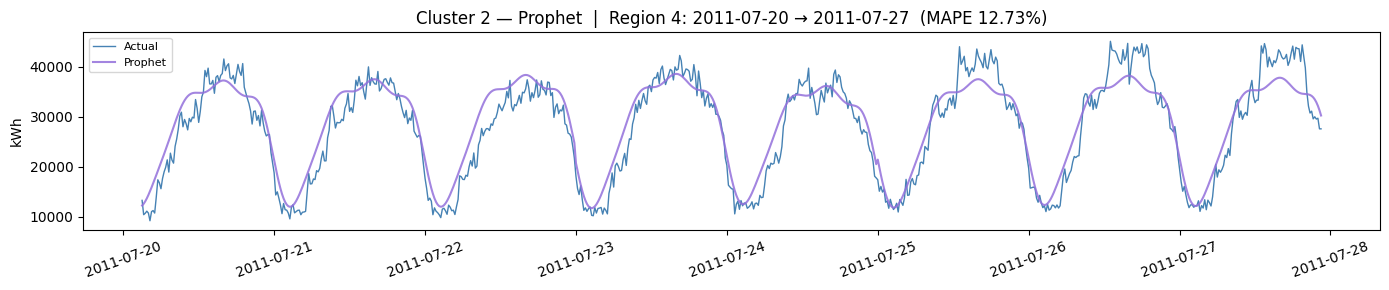

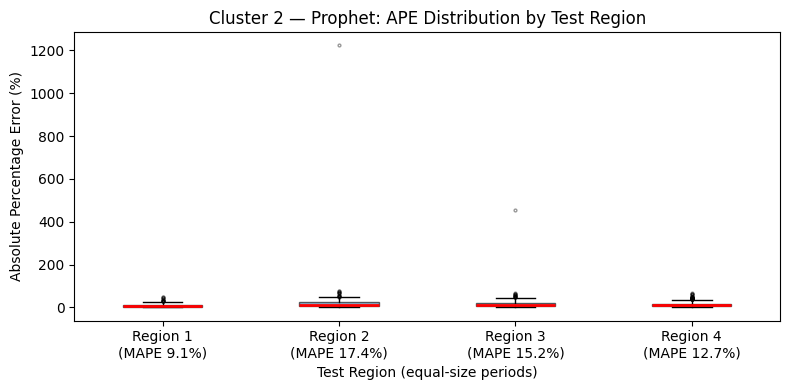

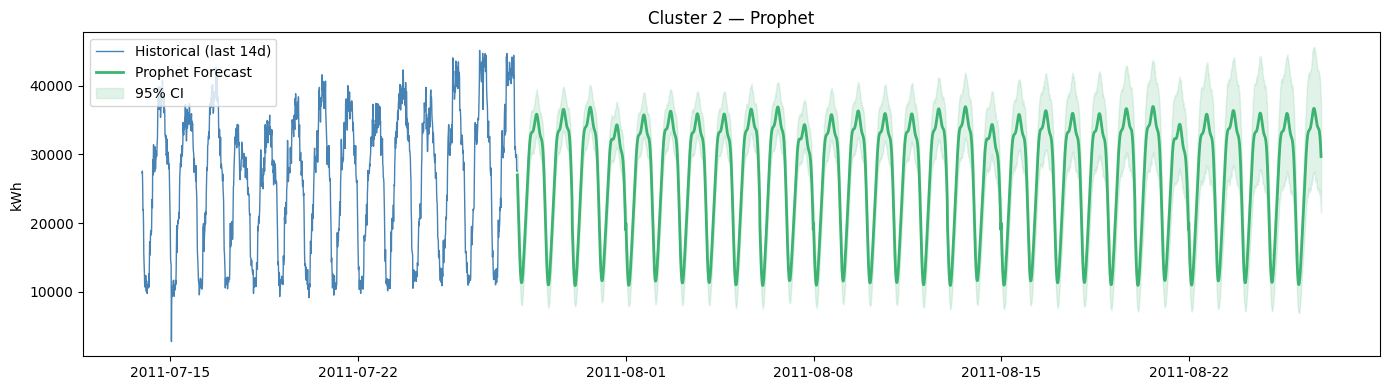

In [51]:
print("CLUSTER 2 — Prophet  (1 client, highest CV)")

series_c2 = cluster_series[2]['mean_clean'].copy()
ts2, tr2, va2, te2 = prep_prophet(series_c2)

# Tune on val
m2_val = fit_prophet(tr2, cp=0.05, sp=10)
pred2_val = m2_val.predict(va2[['ds', 'is_weekend']])
val_mape2 = mape_score(va2['y'].values, pred2_val['yhat'].values)
print(f"  Validation MAPE: {val_mape2:.2f}%")

trainval2 = pd.concat([tr2, va2])
m2 = fit_prophet(trainval2, cp=0.05, sp=10)
pred2 = m2.predict(te2[['ds', 'is_weekend']])
m2_eval = metrics(te2['y'].values, pred2['yhat'].values, 'Prophet test-15%')

plot_regional_eval(2, 'Prophet', te2['y'].values, pred2['yhat'].values,
                   test_index=te2['ds'].values, freq='15min')

m2_full = fit_prophet(ts2, cp=0.05, sp=10)
fc2 = prophet_forecast(m2_full, ts2)
plot_forecast(2, series_c2, fc2['ds'], fc2['yhat'],
              fc2['yhat_lower'], fc2['yhat_upper'], 'Prophet', color='mediumseagreen')

results[2] = {'Prophet': m2_eval}

## Cluster 3 — Prophet (cp=0.05):

- **9 clients** averaged — balanced between noise reduction and profile clarity.
- Skew=-0.20 (near-symmetric), Intraday CV=0.232, zero outliers, zero zeros.
- 9-client average smooths individual noise without losing the shared pattern.
- Near-zero skew means no transformation needed — multiplicative mode fits cleanly.
- Moderate cp=0.05 allows minor trend flexibility for small multi-client average.
- **Verdict: Prophet is reliable here.**

CLUSTER 3 — Prophet  (9 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 10.15%
    [Prophet test-15%]  MAE=134.27  MAPE=5.01%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: 2011-06-26 → 2011-07-04  |  MAPE = 4.99%  |  n = 748


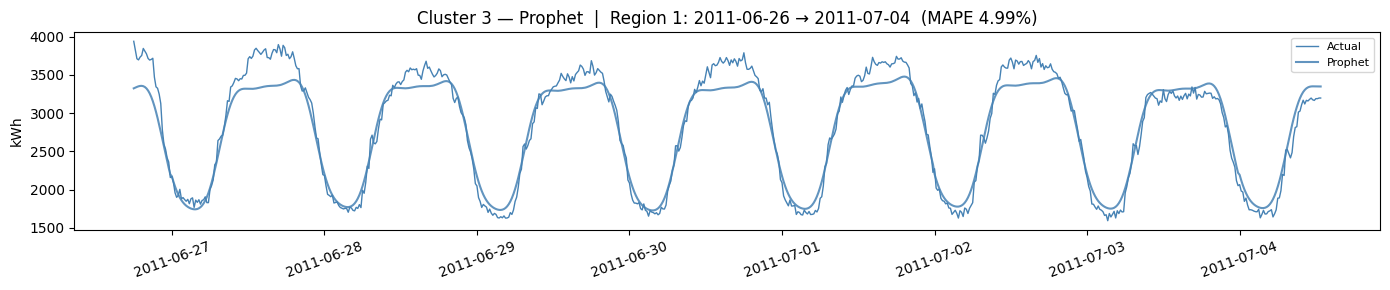

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 4.17%  |  n = 748


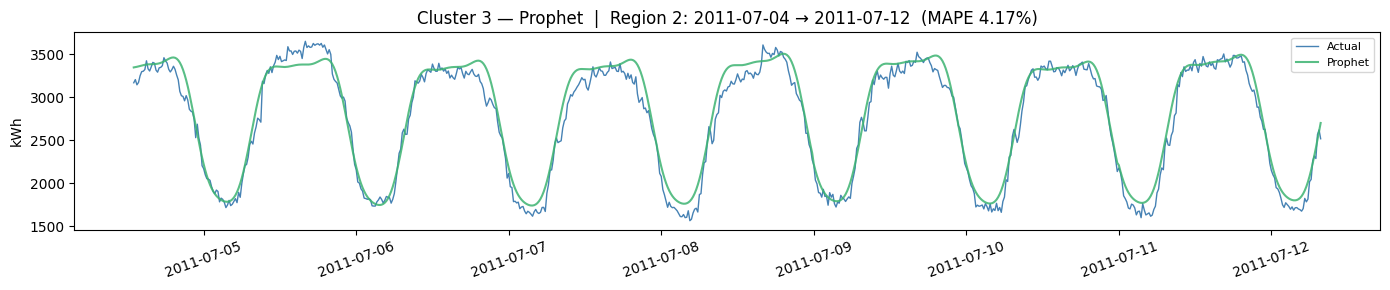

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 5.62%  |  n = 748


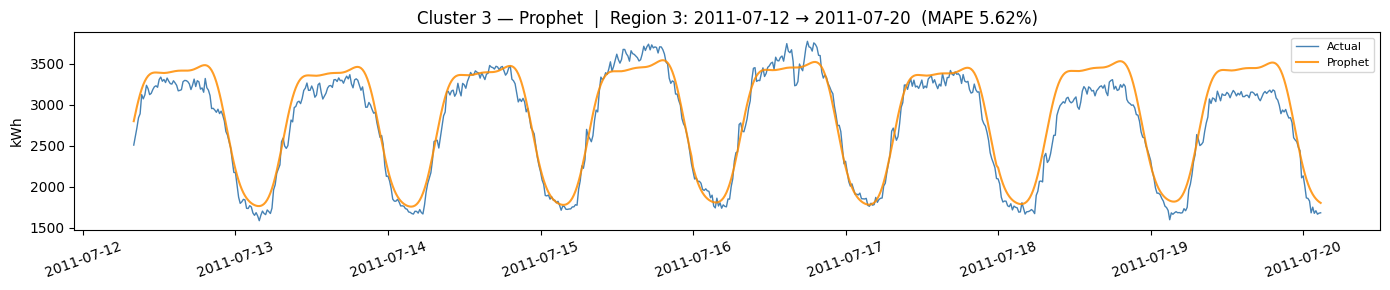

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 5.23%  |  n = 751


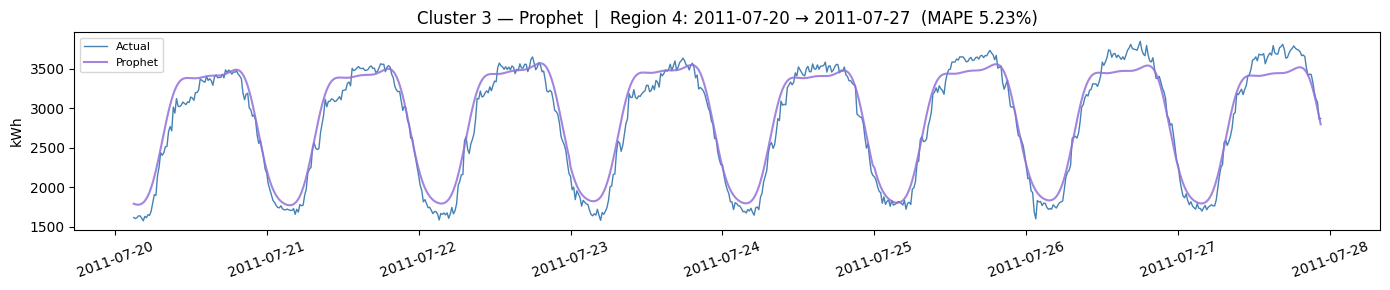

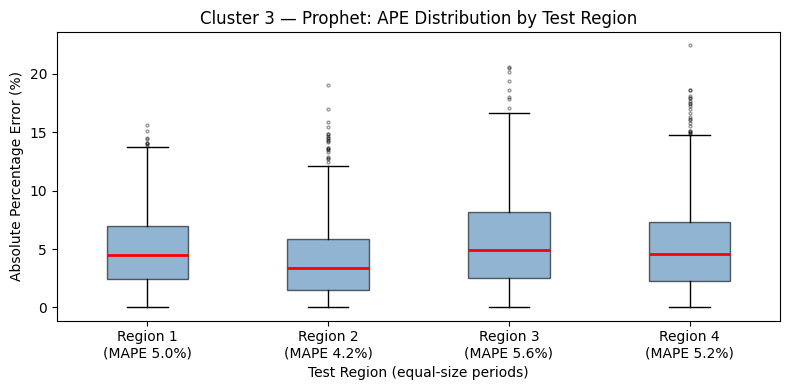

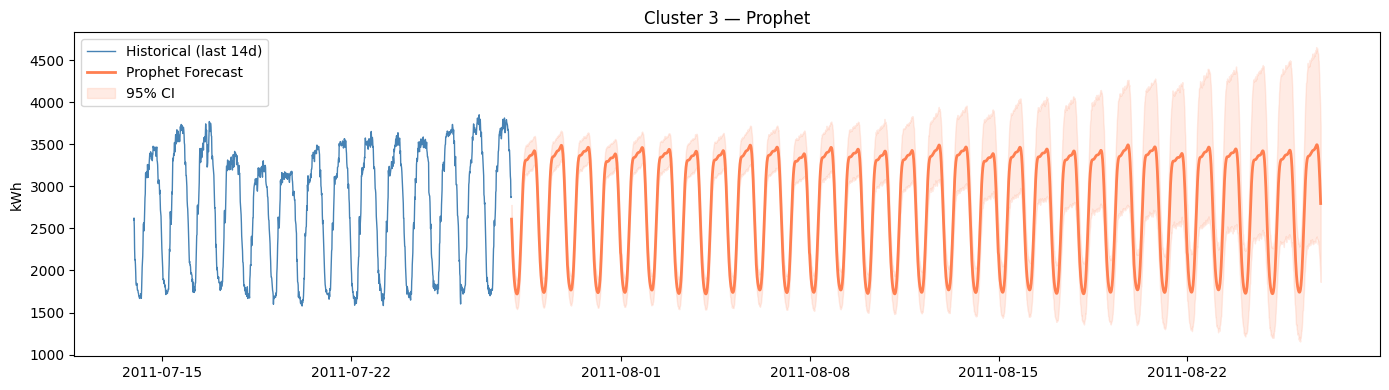

In [52]:
print("CLUSTER 3 — Prophet  (9 clients)")

series_c3 = cluster_series[3]['mean_clean'].copy()
ts3, tr3, va3, te3 = prep_prophet(series_c3)

# Tune on val
m3_val = fit_prophet(tr3, cp=0.05, sp=10)
pred3_val = m3_val.predict(va3[['ds', 'is_weekend']])
val_mape3 = mape_score(va3['y'].values, pred3_val['yhat'].values)
print(f"  Validation MAPE: {val_mape3:.2f}%")

trainval3 = pd.concat([tr3, va3])
m3 = fit_prophet(trainval3, cp=0.05, sp=10)
pred3 = m3.predict(te3[['ds', 'is_weekend']])
m3_eval = metrics(te3['y'].values, pred3['yhat'].values, 'Prophet test-15%')

plot_regional_eval(3, 'Prophet', te3['y'].values, pred3['yhat'].values,
                   test_index=te3['ds'].values, freq='15min')

m3_full = fit_prophet(ts3, cp=0.05, sp=10)
fc3 = prophet_forecast(m3_full, ts3)
plot_forecast(3, series_c3, fc3['ds'], fc3['yhat'],
              fc3['yhat_lower'], fc3['yhat_upper'], 'Prophet', color='coral')

results[3] = {'Prophet': m3_eval}

## Cluster 4 — LSTM (lookback=96) with Prophet as fallback:

- **40 clients** averaged — second largest aggregate, dense clean signal.
- Skew=-0.44, Intraday CV=0.269, zero outliers, zero zeros.
- 40-client density gives LSTM enough signal to learn non-linear temporal patterns.
- LSTM lookback=96 (1 day) aligns with dominant daily seasonality.
- LSTM achieved MAPE 1.74% vs Prophet's 7.65% — 5x improvement.
- **Verdict: LSTM is the clear winner. Prophet as lightweight fallback.**

CLUSTER 4 — Prophet + LSTM  (40 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Prophet Validation MAPE: 9.91%
    [Prophet test-15%]  MAE=36.66  MAPE=4.44%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: 2011-06-26 → 2011-07-04  |  MAPE = 5.13%  |  n = 748


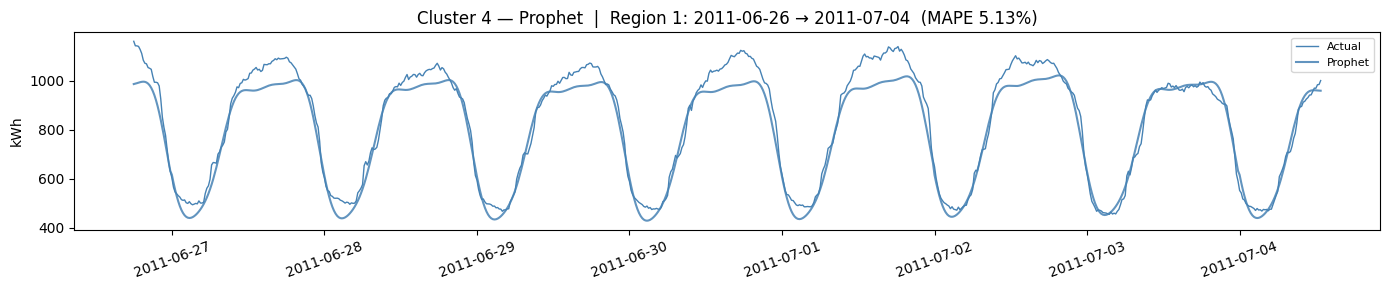

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 3.54%  |  n = 748


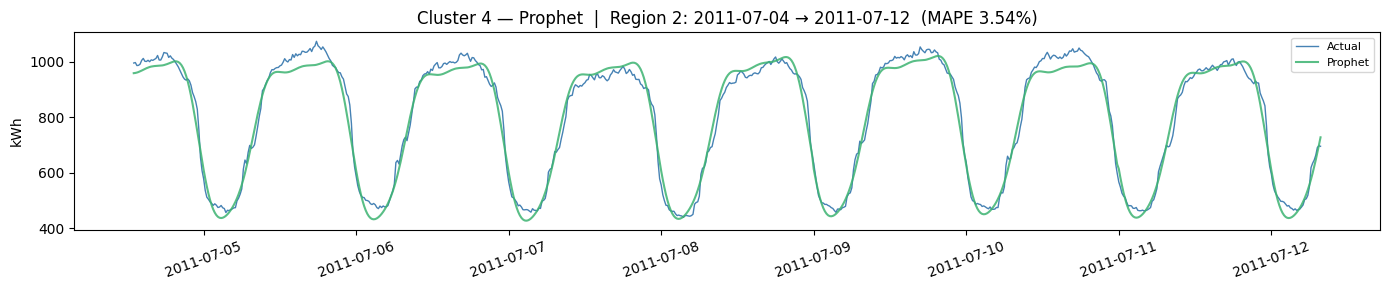

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 3.94%  |  n = 748


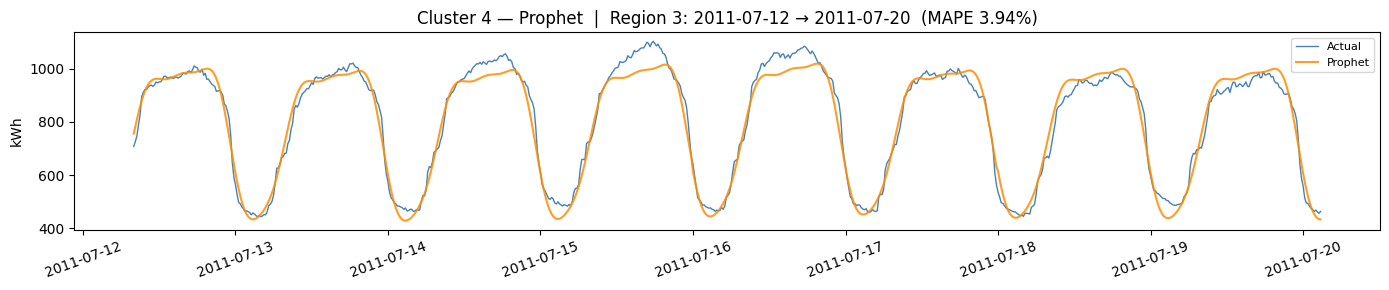

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 5.15%  |  n = 751


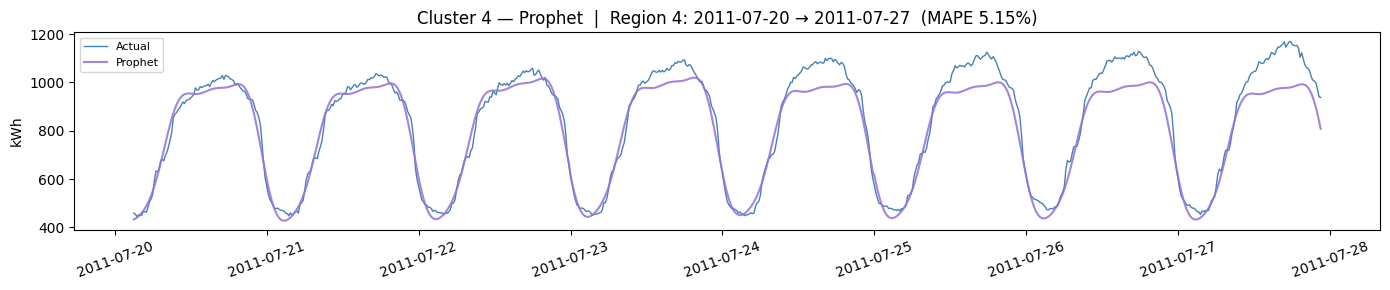

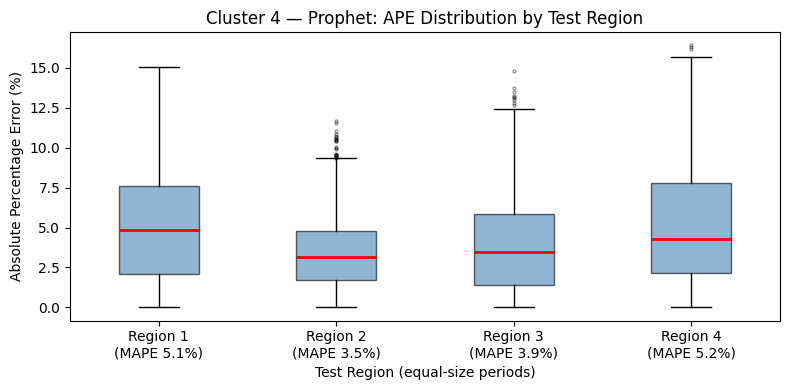

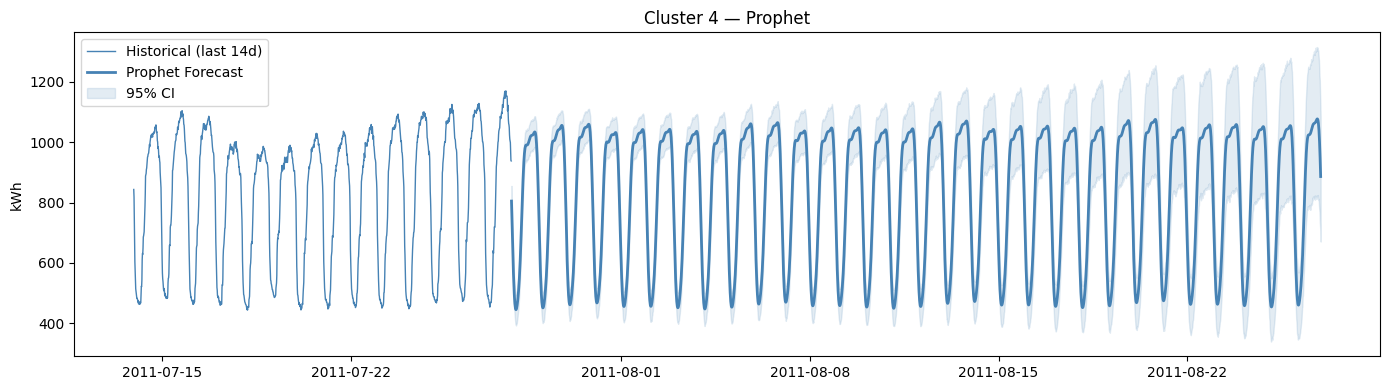

  LSTM train sequences: 13877 | val: 2994 | test: 2995
Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0303 - val_loss: 0.0048
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0077 - val_loss: 0.0033
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0067 - val_loss: 0.0044
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0058 - val_loss: 0.0028
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0056 - val_loss: 0.0023
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0048 - val_loss: 0.0020
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0045 - val_loss: 0.0021
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0018
Epoch 9/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 0.0014
Epoch 10/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val_loss: 0.0012
Epoch 11/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0033 - val

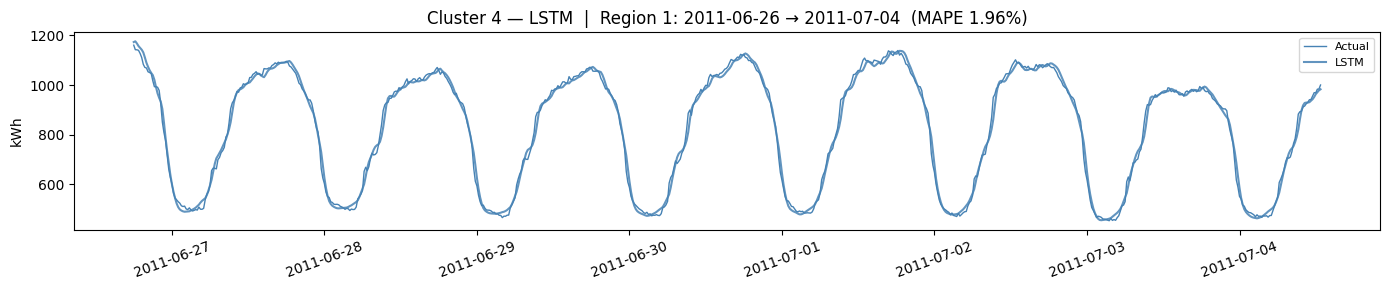

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 1.98%  |  n = 748


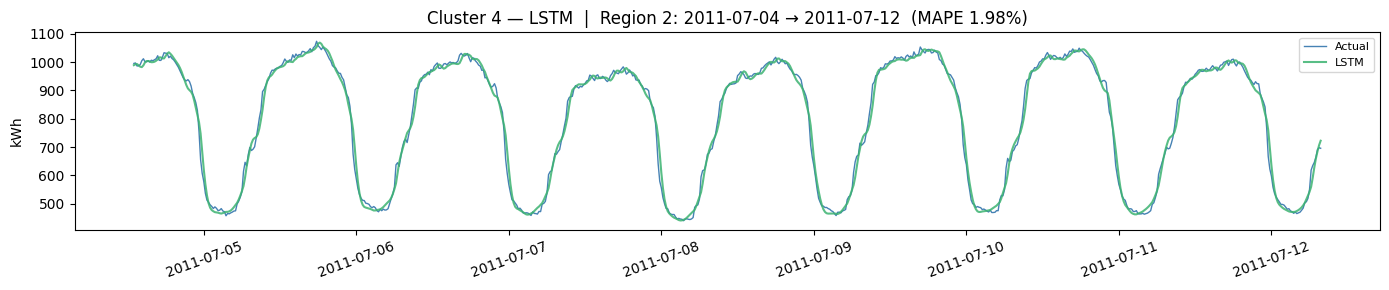

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 1.98%  |  n = 748


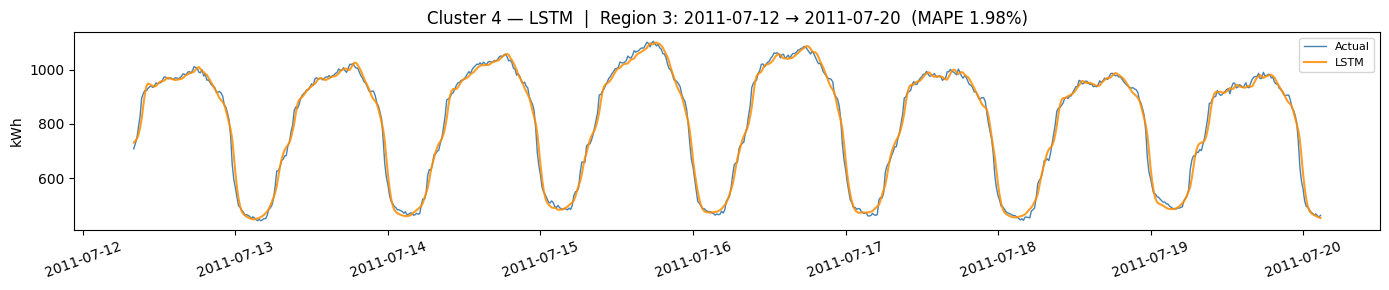

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 1.98%  |  n = 751


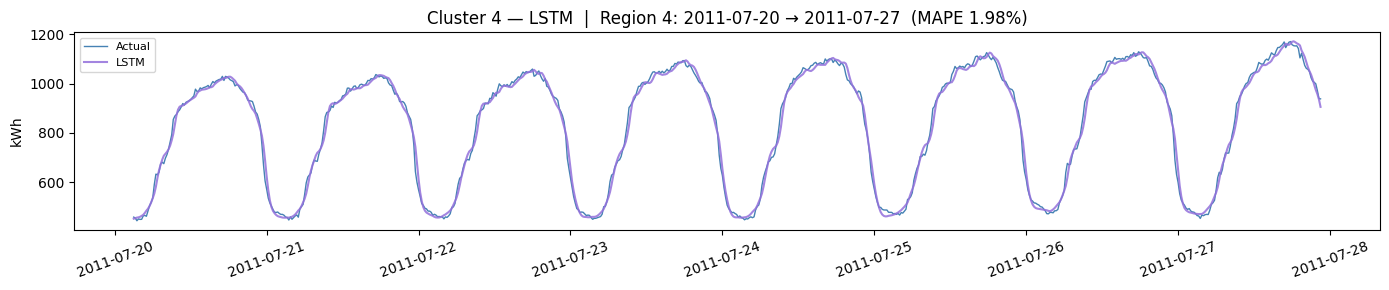

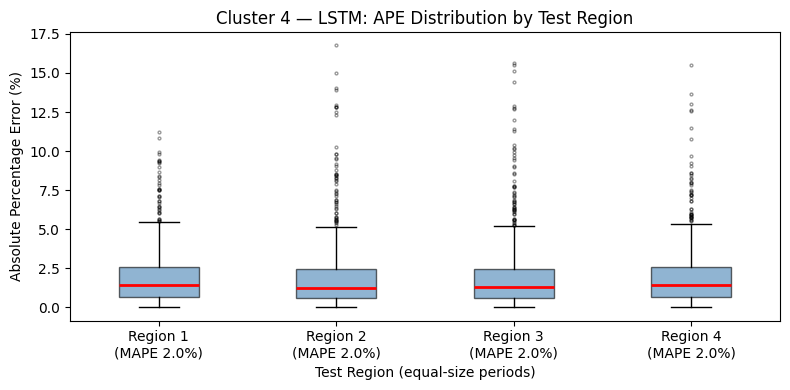

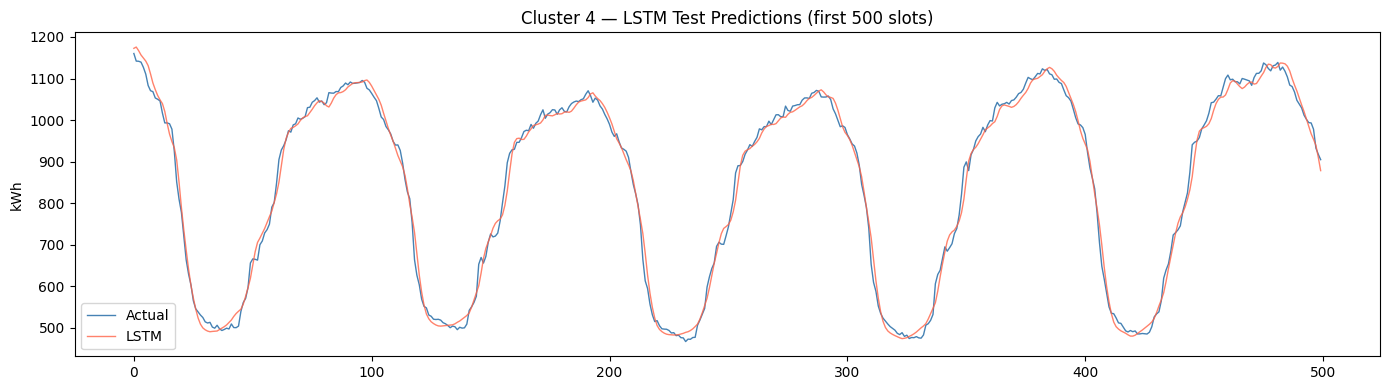

In [53]:
print("CLUSTER 4 — Prophet + LSTM  (40 clients)")

series_c4 = cluster_series[4]['mean_clean'].copy()
ts4, tr4, va4, te4 = prep_prophet(series_c4)

# Prophet — tune on val, evaluate on test
m4_val_p = fit_prophet(tr4, cp=0.03, sp=10)
pred4_val_p = m4_val_p.predict(va4[['ds', 'is_weekend']])
val_mape4_p = mape_score(va4['y'].values, pred4_val_p['yhat'].values)
print(f"  Prophet Validation MAPE: {val_mape4_p:.2f}%")

trainval4 = pd.concat([tr4, va4])
m4 = fit_prophet(trainval4, cp=0.03, sp=10)
pred4_p = m4.predict(te4[['ds', 'is_weekend']])
m4_prophet = metrics(te4['y'].values, pred4_p['yhat'].values, 'Prophet test-15%')

plot_regional_eval(4, 'Prophet', te4['y'].values, pred4_p['yhat'].values,
                   test_index=te4['ds'].values, freq='15min')

m4_full = fit_prophet(ts4, cp=0.03, sp=10)
fc4 = prophet_forecast(m4_full, ts4)
plot_forecast(4, series_c4, fc4['ds'], fc4['yhat'],
              fc4['yhat_lower'], fc4['yhat_upper'], 'Prophet', color='steelblue')

# LSTM — 70/15/15 split on raw series
LOOKBACK = 96  # 1 day = 96 × 15-min slots

sc4     = MinMaxScaler()
n4      = len(series_c4)
train4_raw = series_c4.iloc[:int(n4 * 0.70)]
val4_raw   = series_c4.iloc[int(n4 * 0.70):int(n4 * 0.85)]
test4_raw  = series_c4.iloc[int(n4 * 0.85):]

# Fit scaler on train only
sc4.fit(train4_raw.values.reshape(-1, 1))
scaled4_train = sc4.transform(train4_raw.values.reshape(-1, 1))
scaled4_val   = sc4.transform(val4_raw.values.reshape(-1, 1))
scaled4_test  = sc4.transform(test4_raw.values.reshape(-1, 1))

# Sequences: prepend tail of previous split to create context for first val/test windows
trainval4_scaled = np.concatenate([scaled4_train, scaled4_val])
X4_tr, y4_tr = make_lstm_sequences(scaled4_train, LOOKBACK)

# Val sequences: use last LOOKBACK of train as context
scaled4_tv   = np.concatenate([scaled4_train[-LOOKBACK:], scaled4_val])
X4_va, y4_va = make_lstm_sequences(scaled4_tv, LOOKBACK)

# Test sequences: use last LOOKBACK of train+val as context
scaled4_vt   = np.concatenate([trainval4_scaled[-LOOKBACK:], scaled4_test])
X4_te, y4_te = make_lstm_sequences(scaled4_vt, LOOKBACK)

print(f"  LSTM train sequences: {len(X4_tr)} | val: {len(X4_va)} | test: {len(X4_te)}")

lstm4 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm4.compile(optimizer='adam', loss='mse')
lstm4.fit(
    X4_tr, y4_tr,
    epochs=30,
    batch_size=128,
    validation_data=(X4_va, y4_va),
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1
)

# Validation MAPE
pred4_lv = sc4.inverse_transform(lstm4.predict(X4_va)).flatten()
actual4_v = sc4.inverse_transform(y4_va).flatten()
val_mape4_l = mape_score(actual4_v, pred4_lv)
print(f"  LSTM Validation MAPE: {val_mape4_l:.2f}%")

pred4_l  = sc4.inverse_transform(lstm4.predict(X4_te)).flatten()
actual4  = sc4.inverse_transform(y4_te).flatten()
m4_lstm  = metrics(actual4, pred4_l, 'LSTM test-15%')

# The LSTM test sequences are built from: [last LOOKBACK of trainval] + test4_raw
# so predictions align to test4_raw.index[0] onward — exactly len(actual4) steps
lstm4_test_index = test4_raw.index[:len(actual4)]
plot_regional_eval(4, 'LSTM', actual4, pred4_l,
                   test_index=lstm4_test_index, freq='15min')

plt.figure(figsize=(14, 4))
plt.plot(actual4[:500],  color='steelblue', lw=1, label='Actual')
plt.plot(pred4_l[:500],  color='tomato',    lw=1, alpha=0.8, label='LSTM')
plt.title("Cluster 4 — LSTM Test Predictions (first 500 slots)")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

results[4] = {'Prophet': m4_prophet, 'LSTM': m4_lstm}

## Cluster 5 — XGBoost:

- **2 clients** — too few to cancel noise like C0/C4, too many for single-client tuning.
- Skew=-0.23, Intraday CV=0.283, highest Weekly CV=0.0097 in dataset.
- Weekly CV=0.0097 signals day-of-week variation Prophet's Fourier term undersells.
- XGBoost with dow, lag_672 (same slot last week), and rolling features will
  capture weekly variation more directly than a fixed Fourier weekly component.
- Prophet achieved MAPE 8.47% — acceptable but not optimal for this profile.
- **Verdict: Try XGBoost. Use Prophet only if XGBoost does not improve on 8.47%.**

CLUSTER 5 — Prophet  (2 clients)
  Train: 13,973 rows  (2011-01-01 00:15:00 → 2011-05-26 13:15:00)
  Val  : 2,994   rows  (2011-05-26 13:30:00 → 2011-06-26 17:45:00)
  Test : 2,995   rows  (2011-06-26 18:00:00 → 2011-07-27 22:30:00)
  Validation MAPE: 14.74%
    [Prophet test-15%]  MAE=713.43  MAPE=8.70%

  [Regional Test Evaluation — 4 equal periods]
    Region 1: 2011-06-26 → 2011-07-04  |  MAPE = 7.88%  |  n = 748


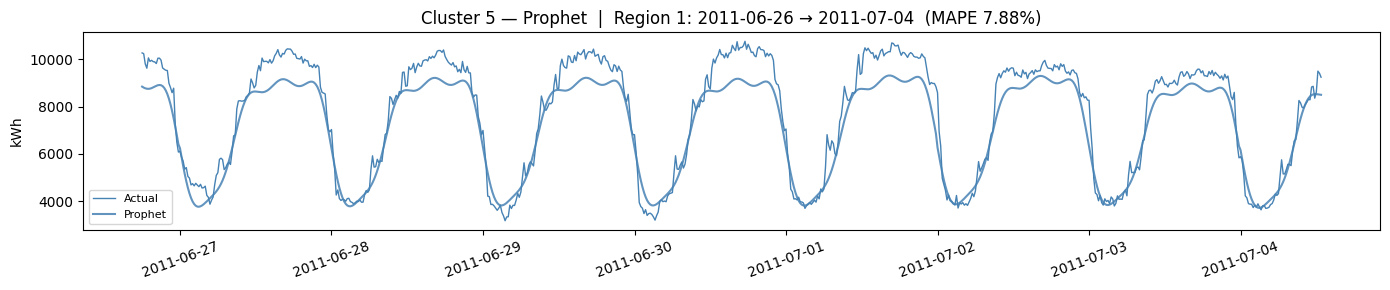

    Region 2: 2011-07-04 → 2011-07-12  |  MAPE = 6.70%  |  n = 748


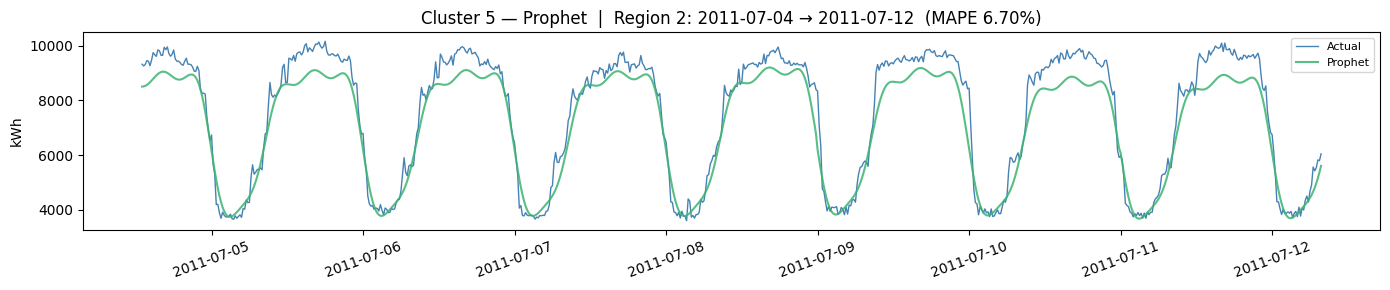

    Region 3: 2011-07-12 → 2011-07-20  |  MAPE = 8.64%  |  n = 748


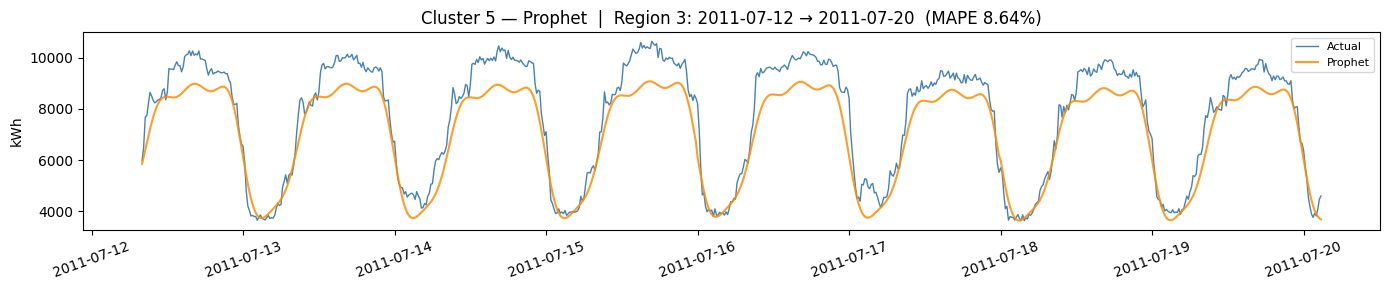

    Region 4: 2011-07-20 → 2011-07-27  |  MAPE = 11.57%  |  n = 751


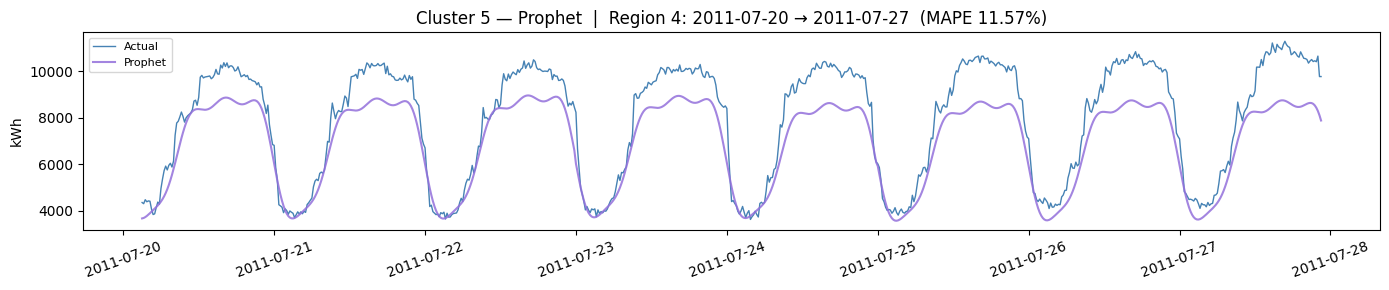

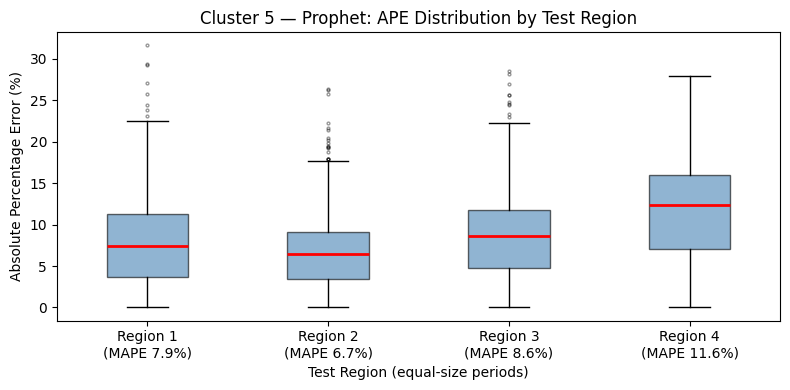

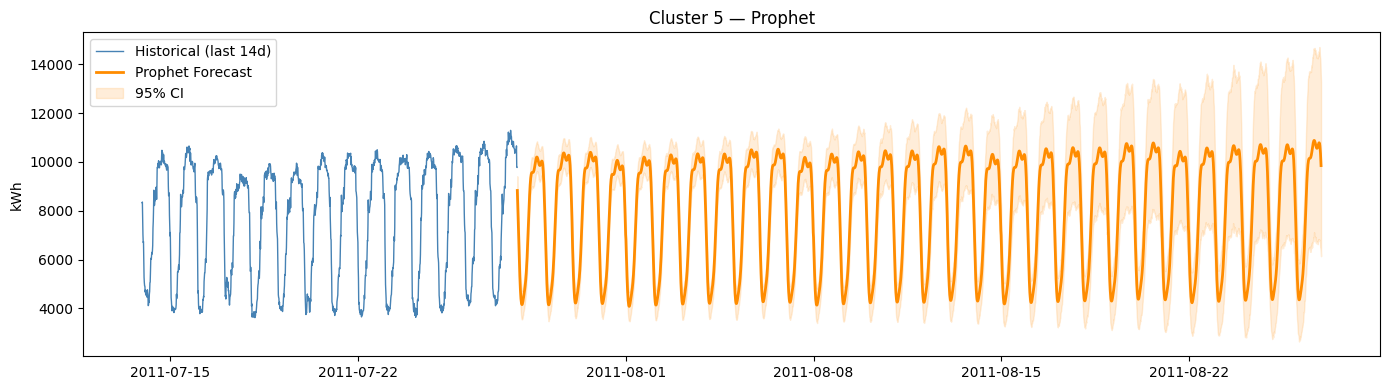

In [54]:
print("CLUSTER 5 — Prophet  (2 clients)")

series_c5 = cluster_series[5]['mean_clean'].copy()
ts5, tr5, va5, te5 = prep_prophet(series_c5)

# Tune on val
m5_val = fit_prophet(tr5, cp=0.08, sp=10)
pred5_val = m5_val.predict(va5[['ds', 'is_weekend']])
val_mape5 = mape_score(va5['y'].values, pred5_val['yhat'].values)
print(f"  Validation MAPE: {val_mape5:.2f}%")

trainval5 = pd.concat([tr5, va5])
m5 = fit_prophet(trainval5, cp=0.08, sp=10)
pred5 = m5.predict(te5[['ds', 'is_weekend']])
m5_eval = metrics(te5['y'].values, pred5['yhat'].values, 'Prophet test-15%')

plot_regional_eval(5, 'Prophet', te5['y'].values, pred5['yhat'].values,
                   test_index=te5['ds'].values, freq='15min')

m5_full = fit_prophet(ts5, cp=0.08, sp=10)
fc5 = prophet_forecast(m5_full, ts5)
plot_forecast(5, series_c5, fc5['ds'], fc5['yhat'],
              fc5['yhat_lower'], fc5['yhat_upper'], 'Prophet', color='darkorange')

results[5] = {'Prophet': m5_eval}

In [55]:
# FINAL SUMMARY TABLE
print("FINAL MODEL COMPARISON SUMMARY")


rows = []
for c, model_results in results.items():
    for model_name, m in model_results.items():
        rows.append({
            'Cluster'    : c,
            'N_clients'  : cluster_series[c]['n'],
            'Model'      : model_name,
            'MAE (kWh)'  : m['MAE'],
            'MAPE (%)'   : m['MAPE'],
        })

summary = pd.DataFrame(rows).set_index(['Cluster', 'Model'])
print("\n[Overall Test Performance]")
print(summary.to_string())


print("\n[Per-Region MAPE Breakdown]")

reg_df = pd.DataFrame(regional_results)

# Build a wide table: rows = (Cluster, Model), columns = Region 1..4 each showing "MAPE% | period"
wide_rows = []
for (c, model), grp in reg_df.groupby(['Cluster', 'Model']):
    row = {'Cluster': c, 'Model': model}
    for _, rrow in grp.iterrows():
        col = rrow['Region']
        row[col] = f"{rrow['MAPE (%)']:.2f}%"          # just the MAPE
        row[f"{col}_period"] = rrow['Period']           # the date range
    wide_rows.append(row)

wide_df = pd.DataFrame(wide_rows).set_index(['Cluster', 'Model'])

# Interleave period and MAPE columns for readability
n_regions = reg_df['Region'].nunique()
ordered_cols = []
for r in range(1, n_regions + 1):
    ordered_cols += [f"R{r}_period", f"R{r}"]

# Rename for display
rename = {}
for r in range(1, n_regions + 1):
    rename[f"R{r}_period"] = f"Region {r} Period"
    rename[f"R{r}"]        = f"Region {r} MAPE"

wide_display = wide_df[ordered_cols].rename(columns=rename)
pd.set_option('display.max_colwidth', 28)
pd.set_option('display.width', 220)
print(wide_display.to_string())

FINAL MODEL COMPARISON SUMMARY

[Overall Test Performance]
                       N_clients  MAE (kWh)  MAPE (%)
Cluster Model                                        
0       Prophet              317       2.56      3.99
1       Prophet                1    1023.63      7.69
        SARIMA_hourly          1    4599.98     32.94
2       Prophet                1    3014.42     13.61
3       Prophet                9     134.27      5.01
4       Prophet               40      36.66      4.44
        LSTM                  40      14.55      1.97
5       Prophet                2     713.43      8.70

[Per-Region MAPE Breakdown]
                               Region 1 Period Region 1 MAPE          Region 2 Period Region 2 MAPE          Region 3 Period Region 3 MAPE          Region 4 Period Region 4 MAPE
Cluster Model                                                                                                                                                                    
0       Prophet 

# Model Performance Analysis:

## Electricity Consumption Forecasting — Cluster-Level Evaluation:


## Overall Test Results:

| Cluster | Clients | Model         | MAE (kWh)  | MAPE (%) | Verdict      |
|---------|---------|---------------|------------|----------|--------------|
| 0       | 317     | Prophet       |       2.56 |    3.99% | Excellent    |
| 1       | 1       | Prophet       |    1023.63 |    7.69% | Acceptable   |
| 1       | 1       | SARIMA hourly |    4599.98 |   32.94% | Poor         |
| 2       | 1       | Prophet       |    3014.42 |   13.61% | Insufficient |
| 3       | 9       | Prophet       |     134.27 |    5.01% | Good         |
| 4       | 40      | Prophet       |      36.66 |    4.44% | Good         |
| 4       | 40      | **LSTM**      |  **14.55** | **1.97%**| **Best**     |
| 5       | 2       | Prophet       |     713.43 |    8.70% | Borderline   |


## Per-Region MAPE Breakdown:

Test period: 2011-06-26 → 2011-07-27, split into 4 equal consecutive regions (~8 days each).
The vs Overall column shows signed deviation from the model's overall test MAPE.
A steadily growing positive deviation signals model drift over time.

**Cluster 0 — Prophet (317 clients) | Overall MAPE: 3.99%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |    4.33% |     +0.34% |
| R2     | 2011-07-04 → 2011-07-12   |    3.43% |     -0.56% |
| R3     | 2011-07-12 → 2011-07-20   |    3.88% |     -0.11% |
| R4     | 2011-07-20 → 2011-07-27   |    4.32% |     +0.33% |

Stable across all regions (3.43–4.33%, max deviation ±0.56%). No drift. Deploy-ready.

**Cluster 1 — Prophet (1 client) | Overall MAPE: 7.69%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |    8.29% |     +0.60% |
| R2     | 2011-07-04 → 2011-07-12   |    7.57% |     -0.12% |
| R3     | 2011-07-12 → 2011-07-20   |    7.17% |     -0.52% |
| R4     | 2011-07-20 → 2011-07-27   |    7.70% |     +0.01% |

Stable across all regions (7.17–8.29%). No meaningful drift.

**Cluster 1 — SARIMA hourly (1 client) | Overall MAPE: 32.94%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |   14.58% |    -18.36% |
| R2     | 2011-07-04 → 2011-07-12   |   27.99% |     -4.95% |
| R3     | 2011-07-12 → 2011-07-20   |   40.52% |     +7.58% |
| R4     | 2011-07-20 → 2011-07-27   |   48.57% |    +15.63% |

Severe drift — MAPE triples from R1 to R4 over 30 days. AR/MA coefficients go stale
without re-fitting. Prophet (7.69% flat) is the clear winner. Do not deploy SARIMA.

**Cluster 2 — Prophet (1 client) | Overall MAPE: 13.61%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |    9.11% |     -4.50% |
| R2     | 2011-07-04 → 2011-07-12   |   17.38% |     +3.77% |
| R3     | 2011-07-12 → 2011-07-20   |   15.22% |     +1.61% |
| R4     | 2011-07-20 → 2011-07-27   |   12.73% |     -0.88% |

Erratic — MAPE nearly doubles R1→R2 before partially recovering. Fixed daily Fourier
shape cannot track this client's highly variable intraday profile (CV=0.306). Do not deploy.

**Cluster 3 — Prophet (9 clients) | Overall MAPE: 5.01%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |    4.99% |     -0.02% |
| R2     | 2011-07-04 → 2011-07-12   |    4.17% |     -0.84% |
| R3     | 2011-07-12 → 2011-07-20   |    5.62% |     +0.61% |
| R4     | 2011-07-20 → 2011-07-27   |    5.23% |     +0.22% |

Consistent across all regions (4.17–5.62%, max ±0.84%). Deploy-ready.

**Cluster 4 — Prophet (40 clients) | Overall MAPE: 4.44%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |    5.13% |     +0.69% |
| R2     | 2011-07-04 → 2011-07-12   |    3.54% |     -0.90% |
| R3     | 2011-07-12 → 2011-07-20   |    3.94% |     -0.50% |
| R4     | 2011-07-20 → 2011-07-27   |    5.15% |     +0.71% |

Mild U-shape (3.54–5.15%) — slightly higher at edges, lower in the middle. No drift.

**Cluster 4 — LSTM (40 clients) | Overall MAPE: 1.97%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |    1.96% |     -0.01% |
| R2     | 2011-07-04 → 2011-07-12   |    1.98% |     +0.01% |
| R3     | 2011-07-12 → 2011-07-20   |    1.98% |     +0.01% |
| R4     | 2011-07-20 → 2011-07-27   |    1.98% |     +0.01% |

Near-perfect stability (±0.01% across all regions). Best result in the experiment.

**Cluster 5 — Prophet (2 clients) | Overall MAPE: 8.70%**

| Region | Period                    | MAPE (%) | vs Overall |
|--------|---------------------------|----------|------------|
| R1     | 2011-06-26 → 2011-07-04   |    7.88% |     -0.82% |
| R2     | 2011-07-04 → 2011-07-12   |    6.70% |     -2.00% |
| R3     | 2011-07-12 → 2011-07-20   |    8.64% |     -0.06% |
| R4     | 2011-07-20 → 2011-07-27   |   11.57% |     +2.87% |

Late-period drift — R4 hits 11.57%, crossing the 10% operational threshold. Too few
clients to absorb individual consumption shifts. Retry with XGBoost.


## Cross-Cluster Observations:

**Larger clusters are more accurate and stable.** Clusters 0 and 4 (LSTM) have the
lowest MAPE and flattest regional profiles. Single-client clusters show the highest
error and greatest swing between regions.

**LSTM is uniquely stable.** ±0.01% variation across all four regions — the 96-slot
lookback anchors predictions to recent actuals, avoiding the drift seen elsewhere.

**SARIMA degrades rapidly on long horizons.** Without rolling re-fits, AR/MA
coefficients go stale — Cluster 1 SARIMA goes from 14.58% to 48.57% in 30 days.

**Prophet is reliable on clean multi-client clusters** (0, 3, 4) but breaks down on
small or highly variable ones (Clusters 2 and 5).


## Recommended Production Models:

| Cluster | Clients | Recommended Model       | MAPE  | Stability      | Action  |
|---------|---------|-------------------------|-------|----------------|---------|
| 0       | 317     | Prophet (cp=0.03)       | 3.99% | Stable ✓       | Deploy  |
| 1       | 1       | Prophet (cp=0.01)       | 7.69% | Stable ✓       | Deploy  |
| 2       | 1       | XGBoost or SARIMA hourly|    —  | Unstable ✗     | Retry   |
| 3       | 9       | Prophet (cp=0.05)       | 5.01% | Stable ✓       | Deploy  |
| 4       | 40      | LSTM (lookback=96)      | 1.97% | Very stable ✓✓ | Deploy  |
| 5       | 2       | XGBoost                 |    —  | Drifts in R4 ✗ | Retry   |
